In [82]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    StackingRegressor)
from xgboost import XGBRegressor

from sklearn import metrics
from sklearn.metrics import (
    r2_score, 
    mean_squared_error, 
    mean_absolute_error)

from sklearn.model_selection import (
    GridSearchCV,
    train_test_split)

In [44]:
data = pd.read_csv('hour.csv')
data.head(3)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [45]:
data.shape, data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


((17379, 17), None)

In [46]:
# check for missing values
data.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [47]:
data[['temp','atemp','hum','windspeed','cnt']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000


In [48]:
data[['temp','atemp','hum','windspeed','cnt']].describe().T

,count,mean,std,min,25%,50%,75%,max
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.8507
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,977.0000


In [49]:
data.nunique()

instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64

In [50]:
# drop id and dteday columns
data.drop(['instant','dteday'],axis=1, inplace=True)

In [51]:
data.head(3)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


### Number of observations in each category

In [52]:
cat_cols = ['season','yr','holiday','workingday','weathersit']
for col in cat_cols:
    print(data[col].value_counts())
    print('-'*30)

season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64
------------------------------
yr
1    8734
0    8645
Name: count, dtype: int64
------------------------------
holiday
0    16879
1      500
Name: count, dtype: int64
------------------------------
workingday
1    11865
0     5514
Name: count, dtype: int64
------------------------------
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64
------------------------------


In [53]:
df = data.copy()

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

In [54]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [55]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Univariate analysis

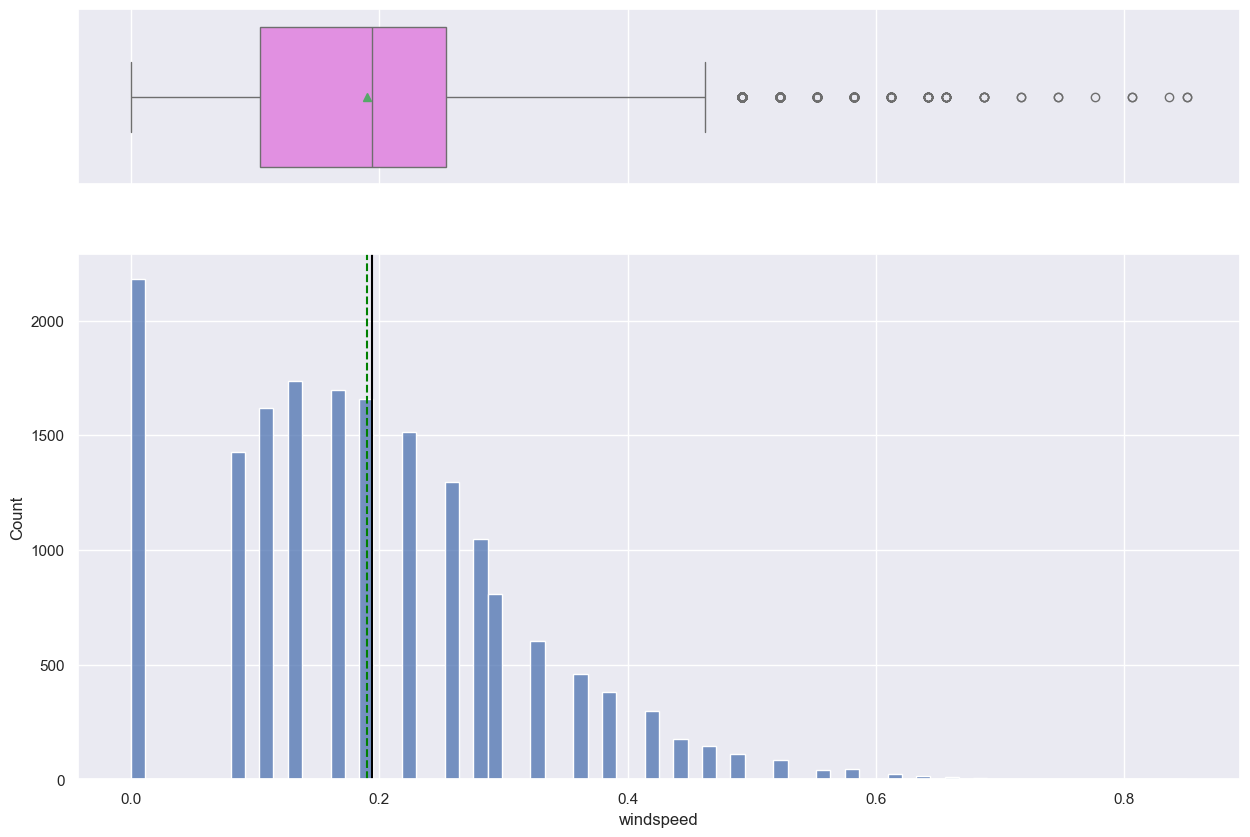

In [56]:
histogram_boxplot(data,'windspeed')

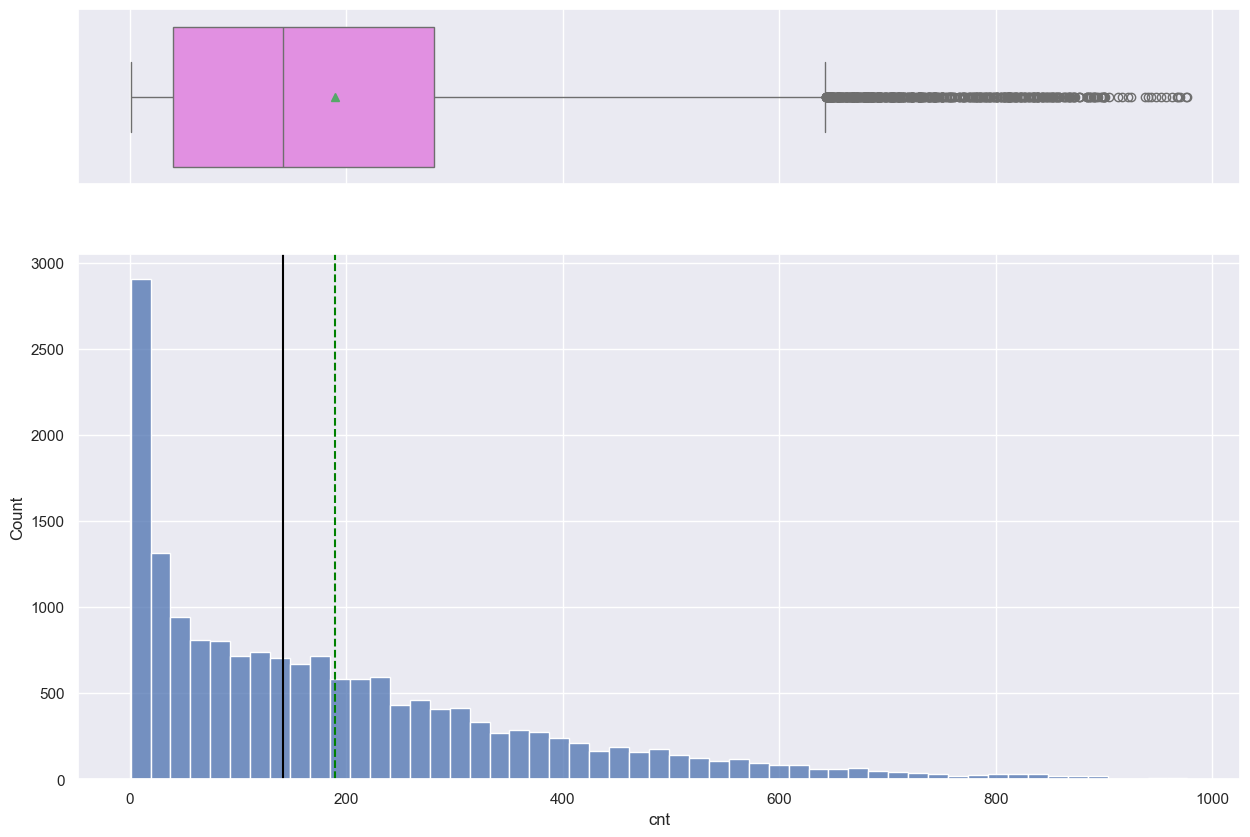

In [57]:
histogram_boxplot(data,'cnt')

In [58]:
data['cnt'].nlargest(5)

14773    977
14964    976
14748    970
14725    968
15084    967
Name: cnt, dtype: int64

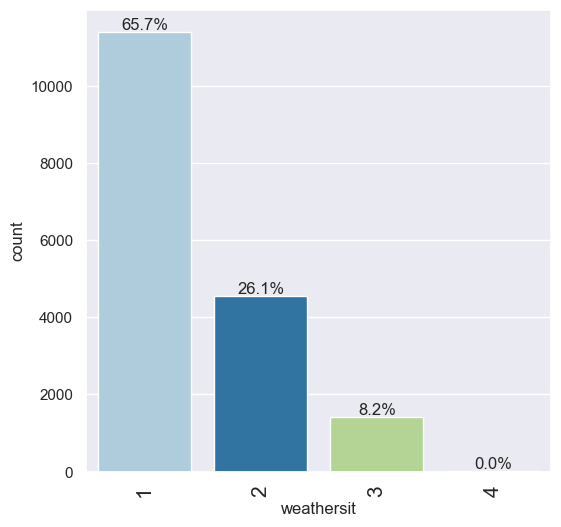

In [59]:
labeled_barplot(data,'weathersit', perc=True)

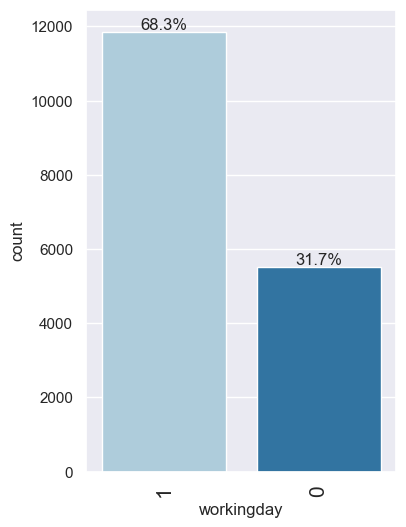

In [60]:
labeled_barplot(data,'workingday',perc=True)

### Bivariate analysis

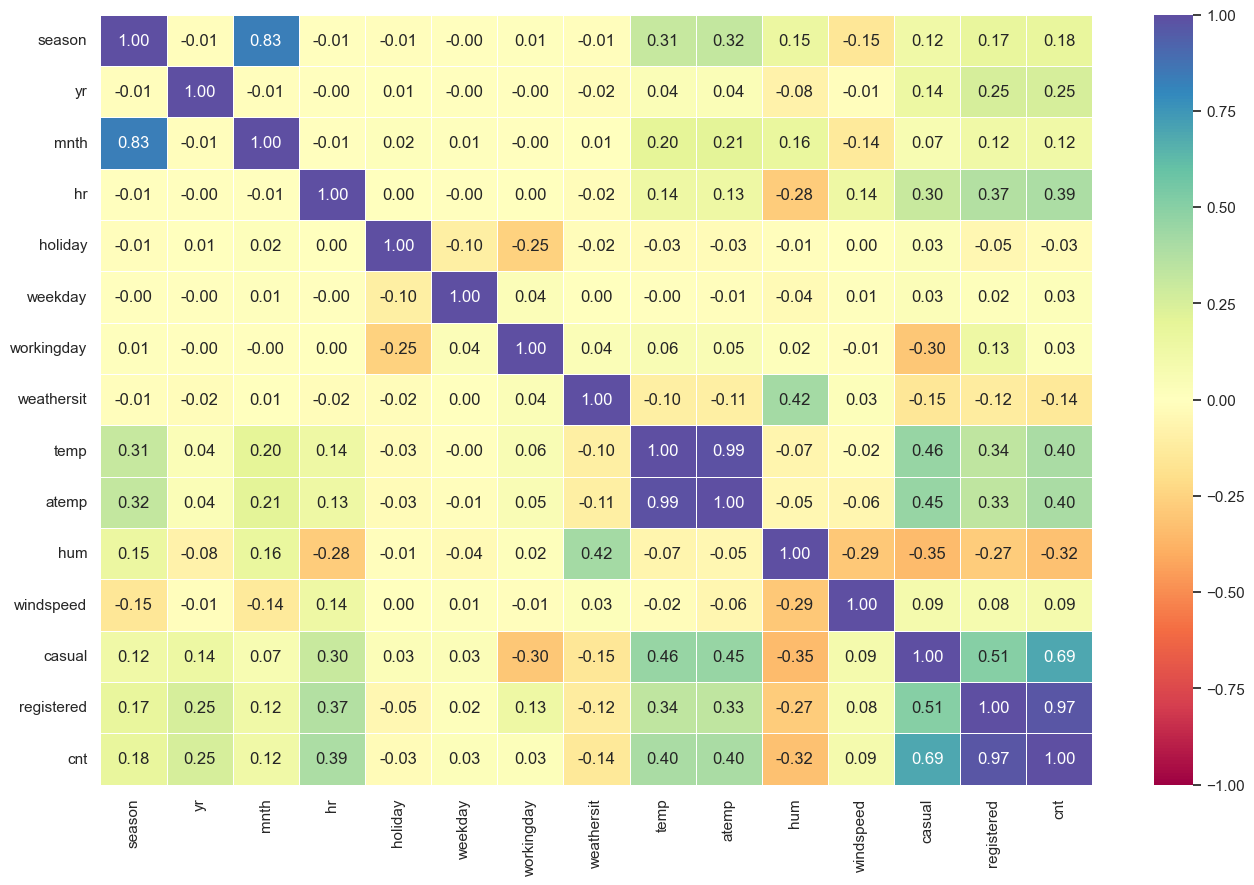

In [61]:
# set the size of seaborn plots to 16*10
sns.set(rc={'figure.figsize':(16,10)})

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            vmin=-1,
            vmax=1,
            linewidth=0.5,
            center=0,
            cbar=True,
            fmt='0.2f',
            cmap='Spectral')
plt.show()

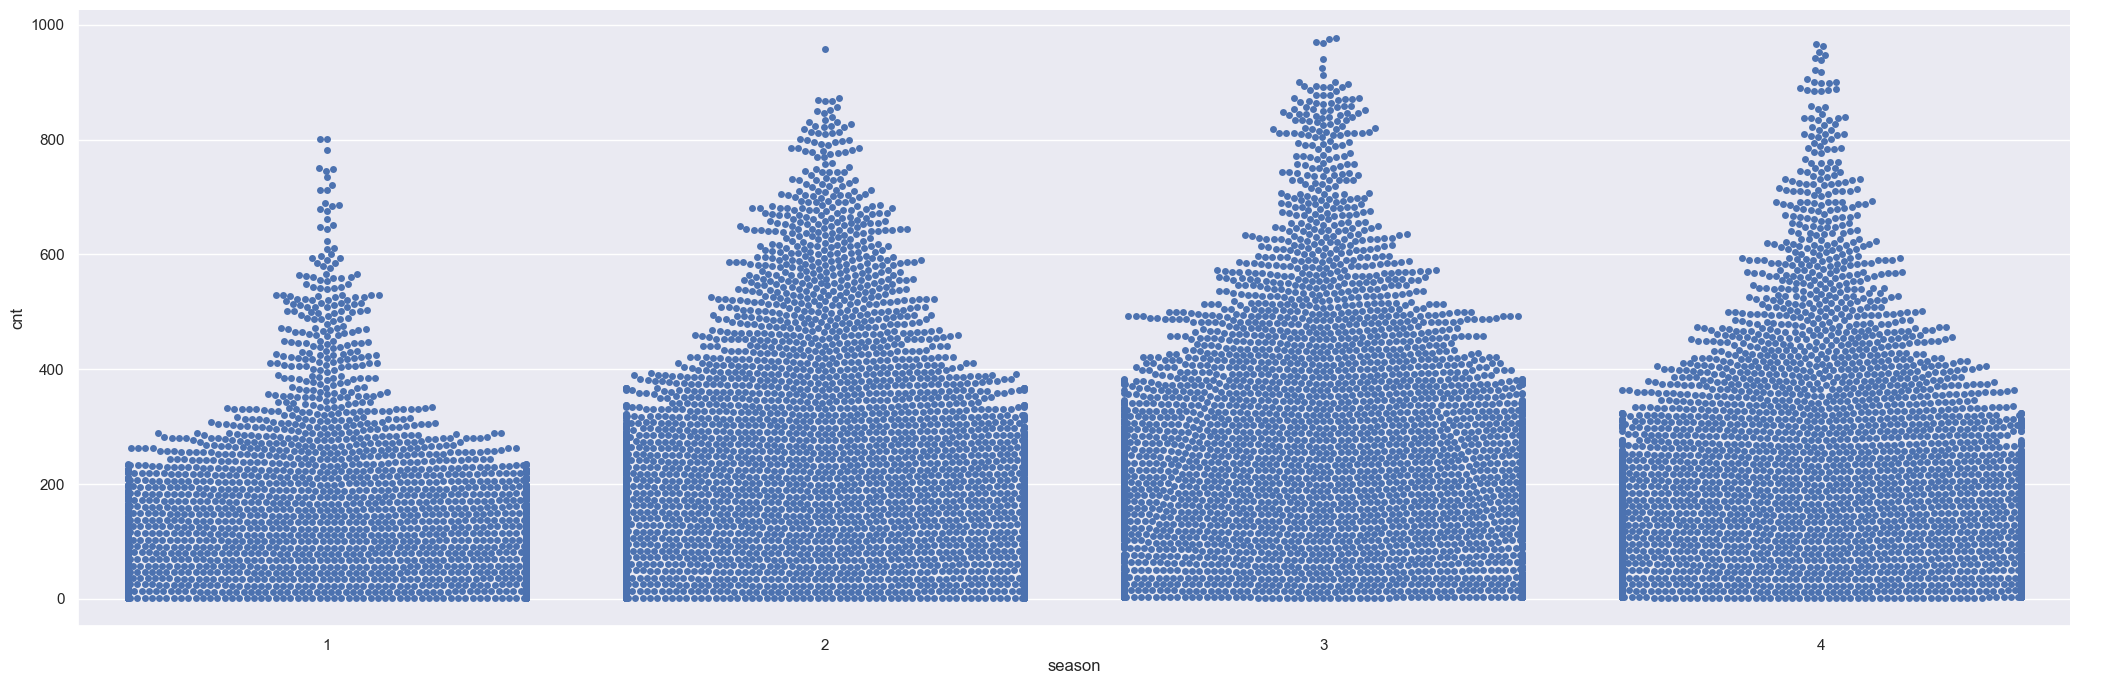

In [63]:
# set the size of seaborn plots to 21*7
sns.set(rc={'figure.figsize':(21,7)})

sns.catplot(x=data['season'],
            y=data['cnt'],
            kind='swarm',
            height=7,
            aspect=3)
plt.show()

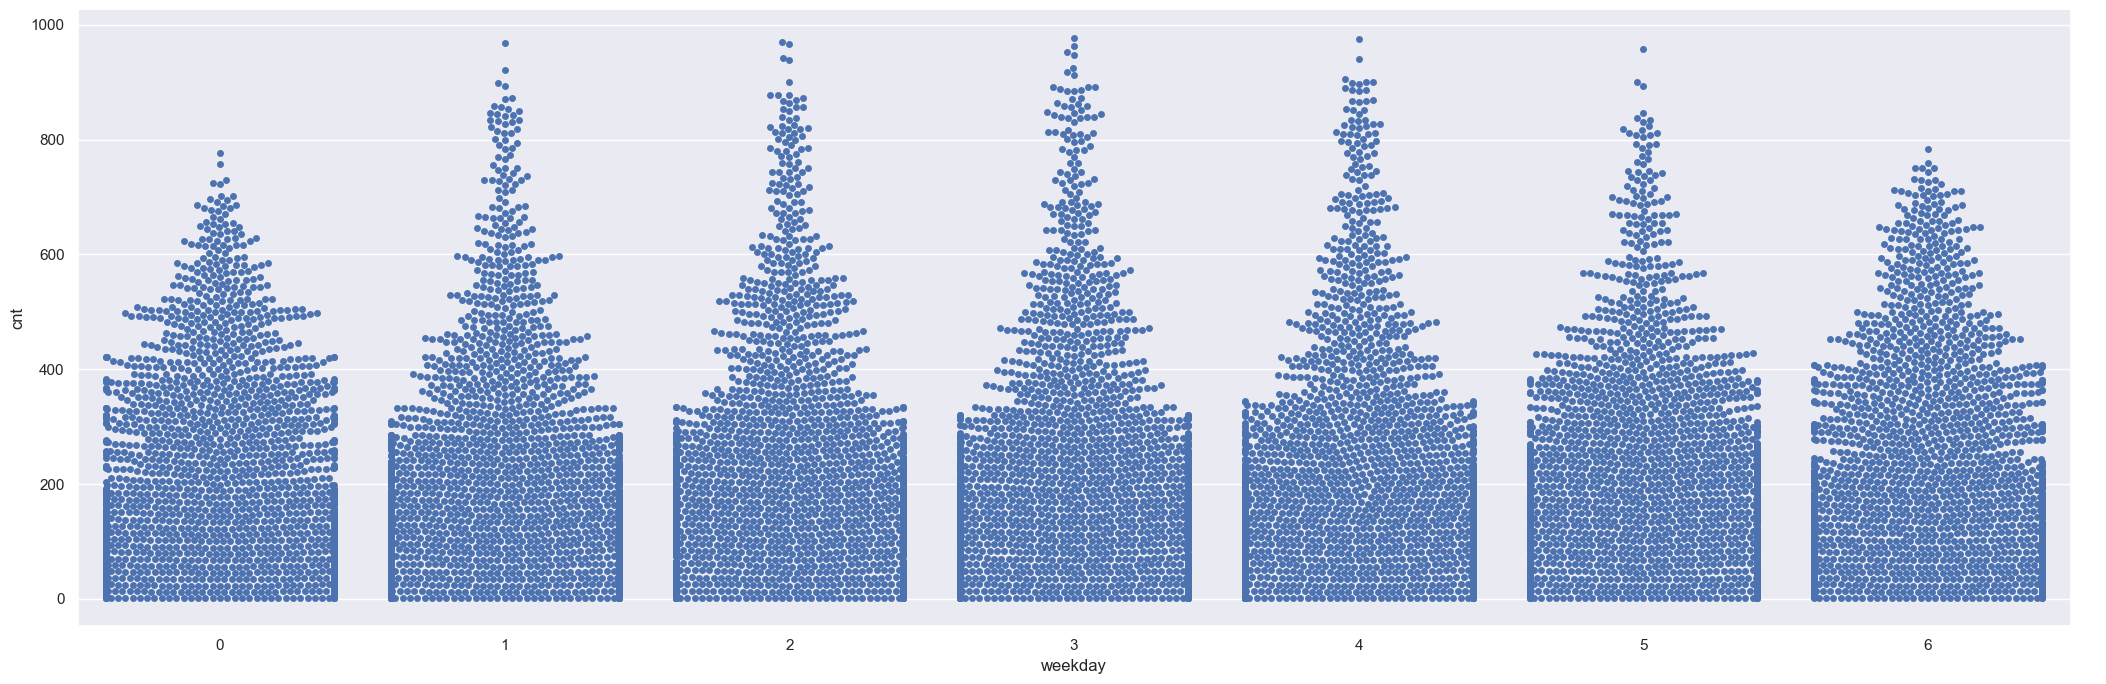

In [64]:
sns.catplot(x=data['weekday'],
            y=data['cnt'],
            kind='swarm',
            height=7,
            aspect=3)
plt.show()

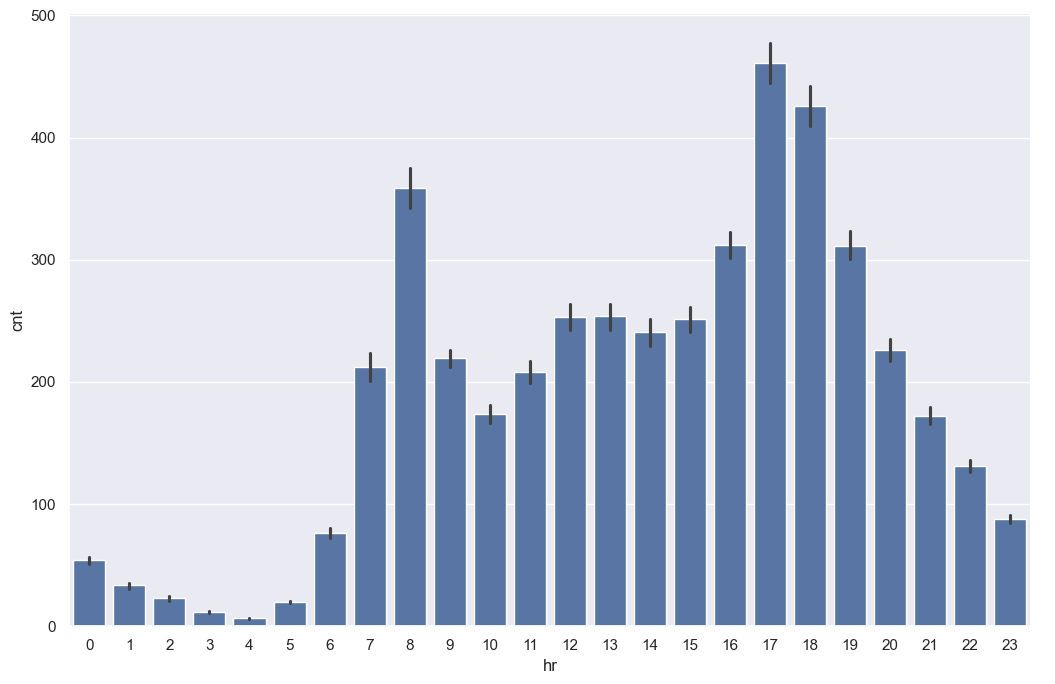

In [66]:
sns.catplot(x=data['hr'],
            y=data['cnt'],
            kind='bar',
            height=7,
            aspect=1.5,
            estimator=np.mean
           )
plt.show()

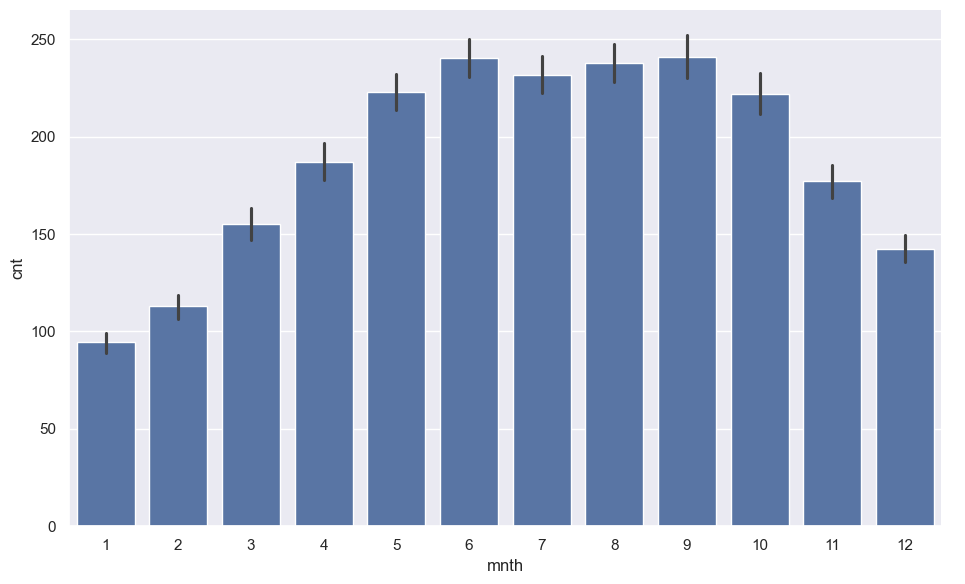

In [70]:
sns.catplot(x=data['mnth'],
            y=data['cnt'],
            kind='bar',
            height=6,
            aspect=1.6,
            estimator=np.mean)
plt.show()

<Figure size 1500x700 with 0 Axes>

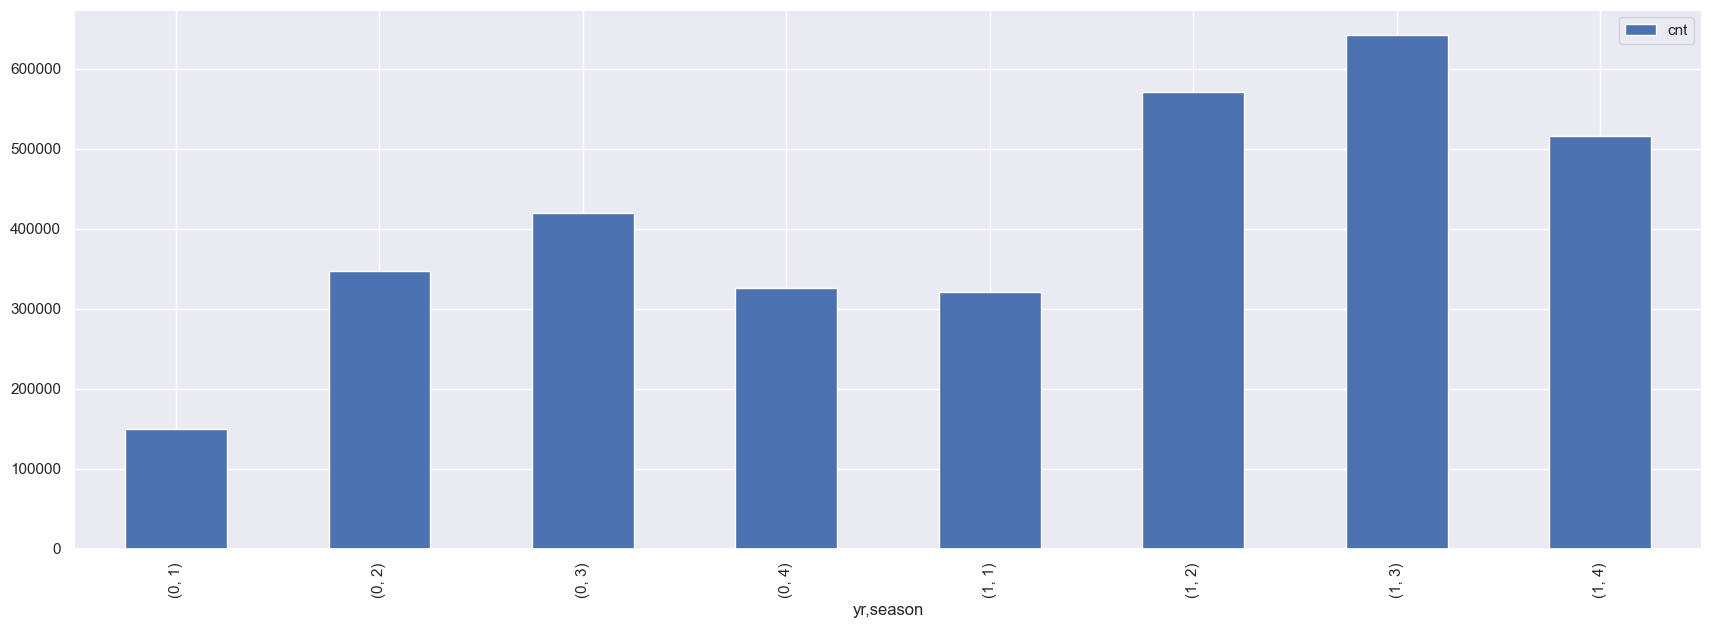

In [71]:
ax = plt.figure(figsize=(15,7))
pd.pivot_table(data=data,
               index=['yr','season'],
               values='cnt',
               aggfunc=np.sum).plot(kind='bar')
plt.show()

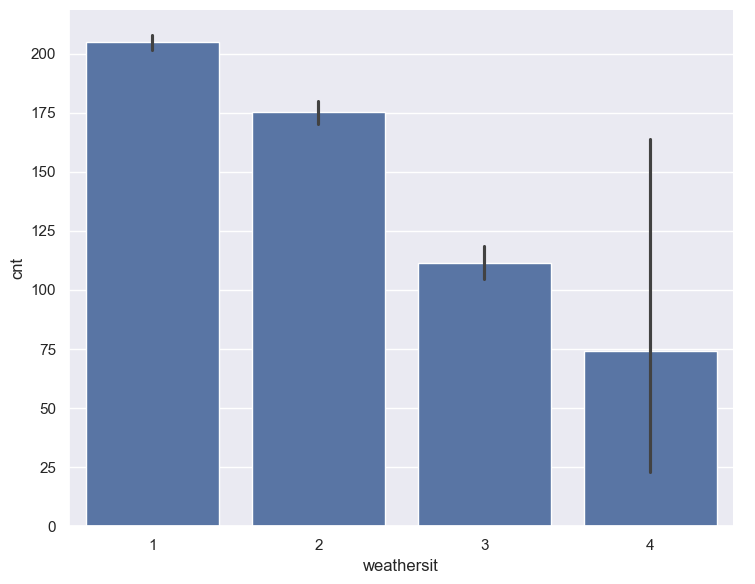

In [72]:
sns.catplot(x=data['weathersit'],
            y=data['cnt'],
            kind='bar',
            height=6,
            aspect=1.25,
            estimator=np.mean)

## Data Preprocessing

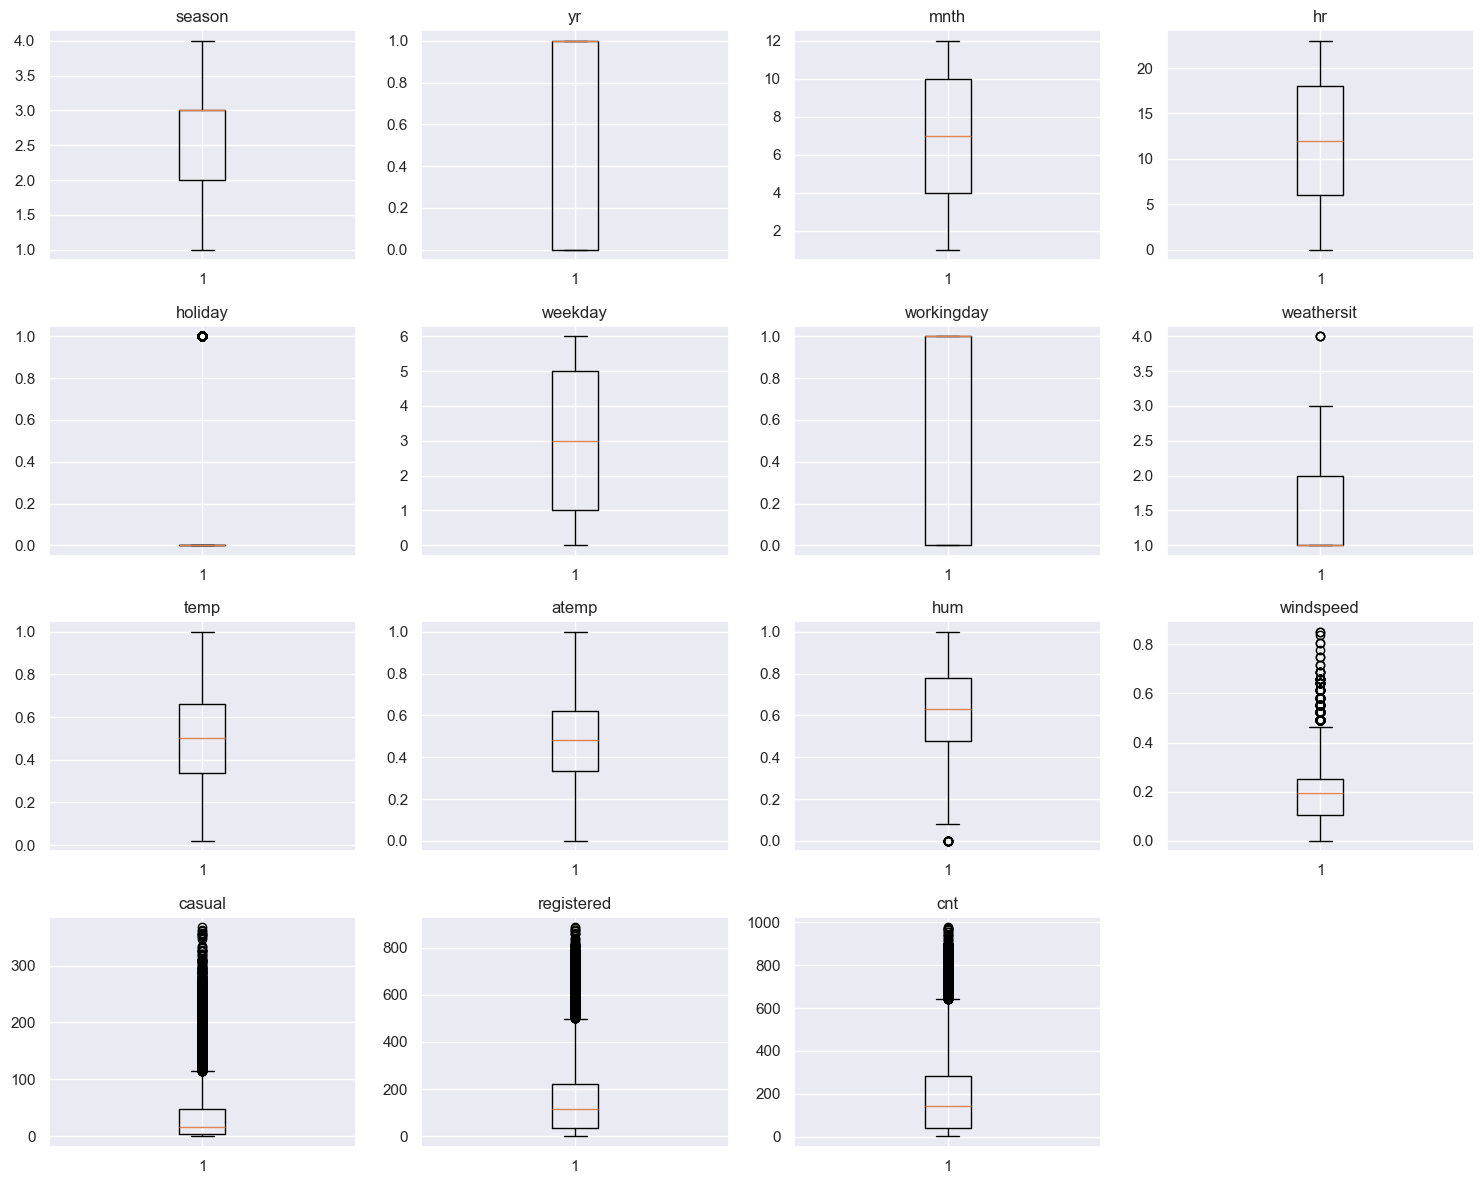

In [73]:
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15,12))
for i, variable in enumerate(numeric_columns):
    plt.subplot(4,4,i+1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)
plt.show()

In [75]:
# drop casual and registered as they are related to cnt column
data.drop(['casual','registered'], axis=1, inplace=True)

In [76]:
X = data.drop('cnt', axis=1)
y = data['cnt']

In [77]:
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.3,
                                     random_state=1,
                                     shuffle=True)
X_train.shape, X_test.shape

((12165, 12), (5214, 12))

## Model Functions

In [85]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1-((1-r2)*(n-1)/(n-k-1))

# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets-predictions)/targets)*100

# function to compute different metrics to check performance of a regression model
def model_performance(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )
    
    return df_perf

In [86]:
#  Function to calculate r2_score and RMSE on train and test data
def get_model_score(model, flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2=metrics.r2_score(y_train,pred_train)
    test_r2=metrics.r2_score(y_test,pred_test)
    train_rmse=np.sqrt(metrics.mean_squared_error(y_train,pred_train))
    test_rmse=np.sqrt(metrics.mean_squared_error(y_test,pred_test))

    #Adding all scores in the list
    score_list.extend((train_r2,test_r2,train_rmse,test_rmse))

    # If the flag is set to True then only the following print statements will be dispayed, the default value is True
    if flag==True:
        print("R-sqaure on training set : ",metrics.r2_score(y_train,pred_train))
        print("R-square on test set : ",metrics.r2_score(y_test,pred_test))
        print("RMSE on training set : ",np.sqrt(metrics.mean_squared_error(y_train,pred_train)))
        print("RMSE on test set : ",np.sqrt(metrics.mean_squared_error(y_test,pred_test)))

    # returning the list with train and test scores
    return score_list

### Decision Tree Model

In [90]:
dtree = DecisionTreeRegressor(random_state=1).fit(X_train, y_train)

dtree_model_train_perf = model_performance(dtree,
                                           X_train,
                                           y_train)
print('Training performance:\n', dtree_model_train_perf)
dtree_model_test_perf = model_performance(dtree,
                                           X_test,
                                           y_test)
print('Testing performance:\n', dtree_model_test_perf)

Training performance:
        RMSE       MAE  R-squared  Adj. R-squared      MAPE
0  0.442409  0.005754   0.999994        0.999994  0.004256
Testing performance:
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  60.827833  35.107787   0.892227        0.891979  38.03325


### Decision Tree Model - Hyperparameter Tuning

In [92]:
dtree_tuned = DecisionTreeRegressor(random_state=1)

parameters = {
    'max_depth':list(np.arange(2,20)) + [None],
    'min_samples_leaf': [1,3,5,7,10],
    'max_leaf_nodes': [2,35,10,15] + [None],
    'min_impurity_decrease': [0.001,0.01,0.1,0.0]}

scorer = metrics.make_scorer(metrics.r2_score)

grid_obj = GridSearchCV(dtree_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train, y_train)
dtree_tuned = grid_obj.best_estimator_
dtree_tuned.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=14, min_impurity_decrease=0.1,
                      min_samples_leaf=5, random_state=1)

In [93]:
dtree_tuned_model_train_perf = model_performance(dtree_tuned, X_train,y_train)
print("Training performance \n",dtree_tuned_model_train_perf)

dtree_tuned_model_test_perf = model_performance(dtree_tuned, X_test,y_test)
print("Testing performance \n",dtree_tuned_model_test_perf)

Training performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  36.442792  22.525337   0.958856        0.958816  28.657314
Testing performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  54.969957  31.841364   0.911985        0.911782  38.356397


In [94]:
print(pd.DataFrame(dtree_tuned.feature_importances_,
                   columns=['Imp'],
                   index=X_train.columns)
      .sort_values(by = 'Imp', ascending=False))

                 Imp
hr          0.634942
temp        0.117441
yr          0.079271
workingday  0.063920
season      0.022164
atemp       0.019463
weathersit  0.019460
hum         0.017227
mnth        0.010498
weekday     0.010009
windspeed   0.003882
holiday     0.001724


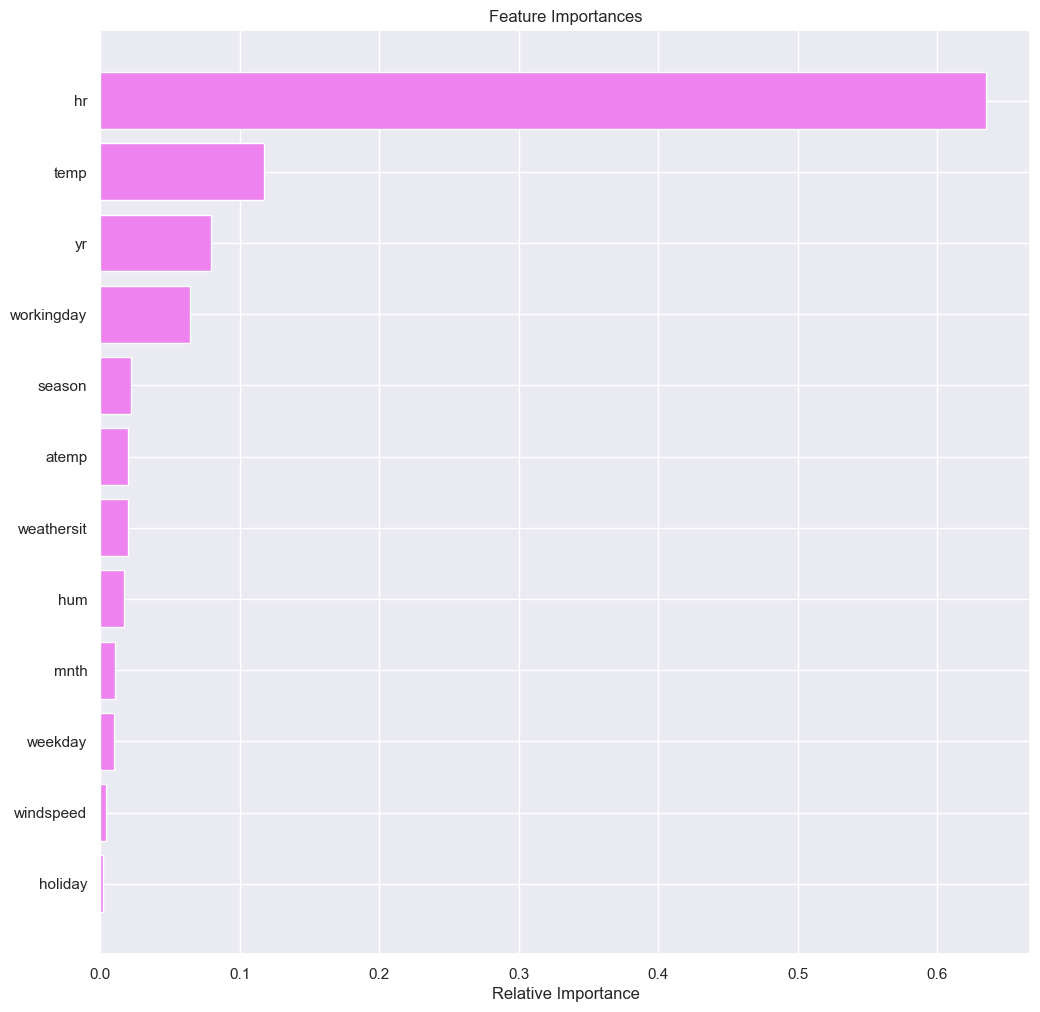

In [95]:
feature_names = X_train.columns
importances = dtree_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), 
         importances[indices], 
         color='violet', 
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Random Forest Model

In [97]:
rf_estimator = RandomForestRegressor(random_state=1).fit(X_train, y_train)

rf_estimator_model_train_perf = model_performance(rf_estimator, X_train,y_train)
print("Training performance \n",rf_estimator_model_train_perf)

rf_estimator_model_test_perf = model_performance_regression(rf_estimator, X_test,y_test)
print("Testing performance \n",rf_estimator_model_test_perf)

Training performance 
         RMSE       MAE  R-squared  Adj. R-squared       MAPE
0  16.167421  9.641324   0.991902        0.991894  11.757327
Testing performance 
        RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  44.56215  26.192368   0.942159        0.942026  32.748634


### Random Forest - Hyperparameter Tuning

In [98]:
rf_tuned = RandomForestRegressor(random_state=1)

parameters = {
     'max_depth': [4,6,8,10, None],
     'max_features': ['sqrt','log2', None],
     'n_estimators': [80,90,100,110,120]}

scorer = metrics.make_scorer(metrics.r2_score)
grid_obj = GridSearchCV(rf_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train, y_train)
rf_tuned = grid_obj.best_estimator_
rf_tuned.fit(X_train, y_train)

RandomForestRegressor(max_features=None, n_estimators=120, random_state=1)

In [99]:
rf_tuned_model_train_perf = model_performance(rf_tuned, X_train, y_train)
print("Training performance \n",rf_tuned_model_train_perf)

rf_tuned_model_test_perf = model_performance(rf_tuned, X_test, y_test)
print("Testing performance \n",rf_tuned_model_test_perf)

Training performance 
         RMSE       MAE  R-squared  Adj. R-squared      MAPE
0  16.160093  9.622604    0.99191        0.991902  11.73432
Testing performance 
       RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  44.5806  26.202363   0.942111        0.941977  32.734172


In [101]:
print(pd.DataFrame(rf_tuned.feature_importances_, 
                   columns = ["Imp"], 
                   index = X_train.columns)
      .sort_values(by = 'Imp', ascending = False))

                 Imp
hr          0.610116
temp        0.121773
yr          0.076295
workingday  0.059489
hum         0.026844
weathersit  0.020962
season      0.020876
atemp       0.020670
mnth        0.016153
weekday     0.013539
windspeed   0.010510
holiday     0.002774


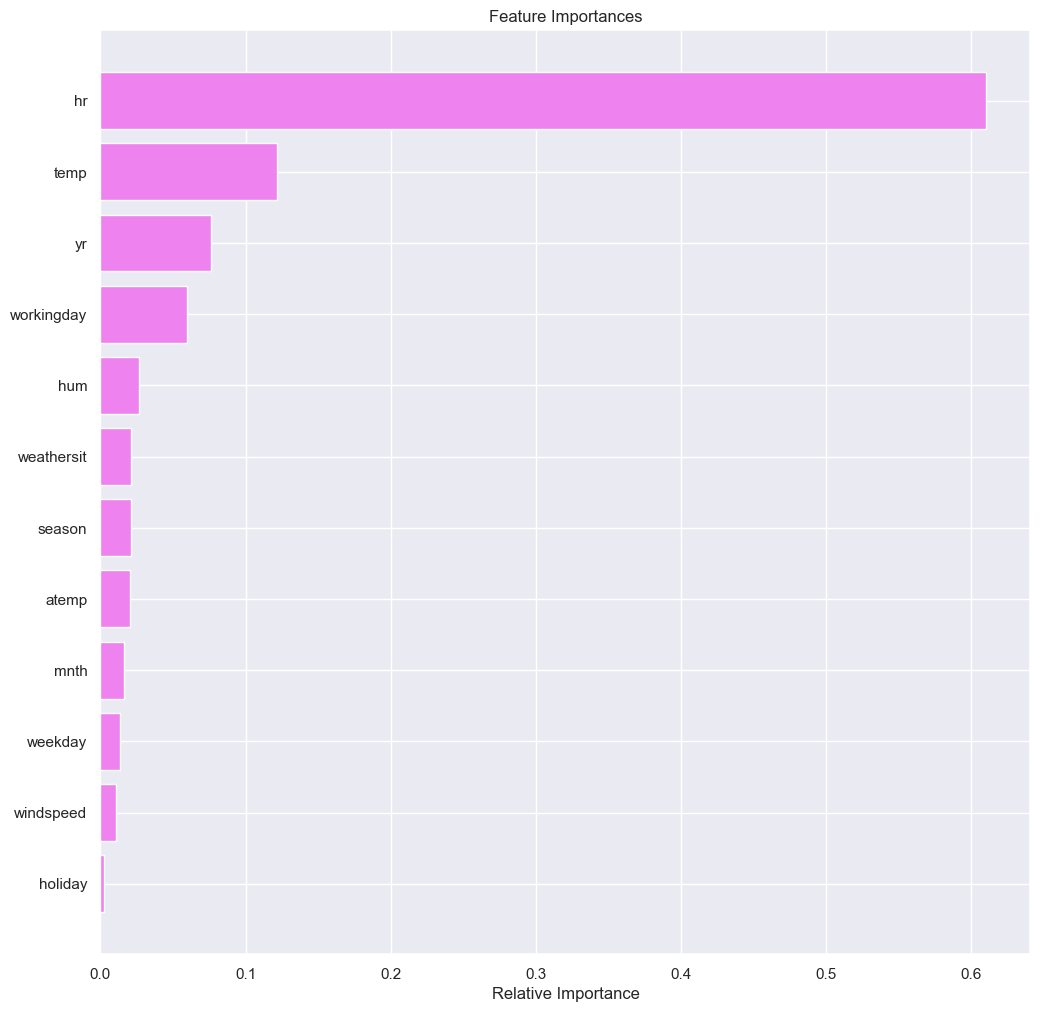

In [102]:
feature_names = X_train.columns
importances = rf_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), 
         importances[indices], 
         color='violet', 
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Adaboost Regressor

In [103]:
ab_regressor=AdaBoostRegressor(random_state=1).fit(X_train, y_train)

ab_regressor_model_train_perf = model_performance(ab_regressor, X_train,y_train)
print("Training performance \n",ab_regressor_model_train_perf)

ab_regressor_model_test_perf = model_performance(ab_regressor, X_test,y_test)
print("Testing performance \n",ab_regressor_model_test_perf)

Training performance 
          RMSE        MAE  R-squared  Adj. R-squared        MAPE
0  104.441843  80.996029   0.662067        0.661733  185.877344
Testing performance 
          RMSE        MAE  R-squared  Adj. R-squared        MAPE
0  105.415729  81.468364   0.676321        0.675574  196.403082


### Adaboost Regressor - Hyperparameter Tuning

In [104]:
ab_tuned = AdaBoostRegressor(random_state=1)

parameters = {
    'n_estimators': np.arange(10,100,10),
    'learning_rate': [0.01, 0.1, 0.5, 1]}

scorer = metrics.make_scorer(metrics.r2_score)

grid_obj = GridSearchCV(ab_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train, y_train)
ab_tuned = grid_obj.best_estimator_
ab_tuned.fit(X_train, y_train)

AdaBoostRegressor(learning_rate=1, n_estimators=30, random_state=1)

In [106]:
ab_tuned_model_train_perf = model_performance(ab_tuned,
                                              X_train,
                                              y_train)
print("Training performance \n",ab_tuned_model_train_perf)
      
ab_tuned_model_test_perf = model_performance(ab_tuned,
                                             X_test,
                                             y_test)
print("Testing performance \n",ab_tuned_model_test_perf)      

Training performance 
          RMSE        MAE  R-squared  Adj. R-squared        MAPE
0  103.326379  80.468809   0.669247         0.66892  195.189129
Testing performance 
          RMSE        MAE  R-squared  Adj. R-squared        MAPE
0  104.430458  81.015165   0.682343         0.68161  207.467888


In [107]:
print(pd.DataFrame(ab_tuned.feature_importances_, 
                   columns = ["Imp"], 
                   index = X_train.columns)
      .sort_values(by = 'Imp', ascending = False))

                 Imp
hr          0.523674
yr          0.135837
atemp       0.076841
workingday  0.058274
season      0.049087
weathersit  0.047040
hum         0.046359
mnth        0.036370
temp        0.026518
holiday     0.000000
weekday     0.000000
windspeed   0.000000


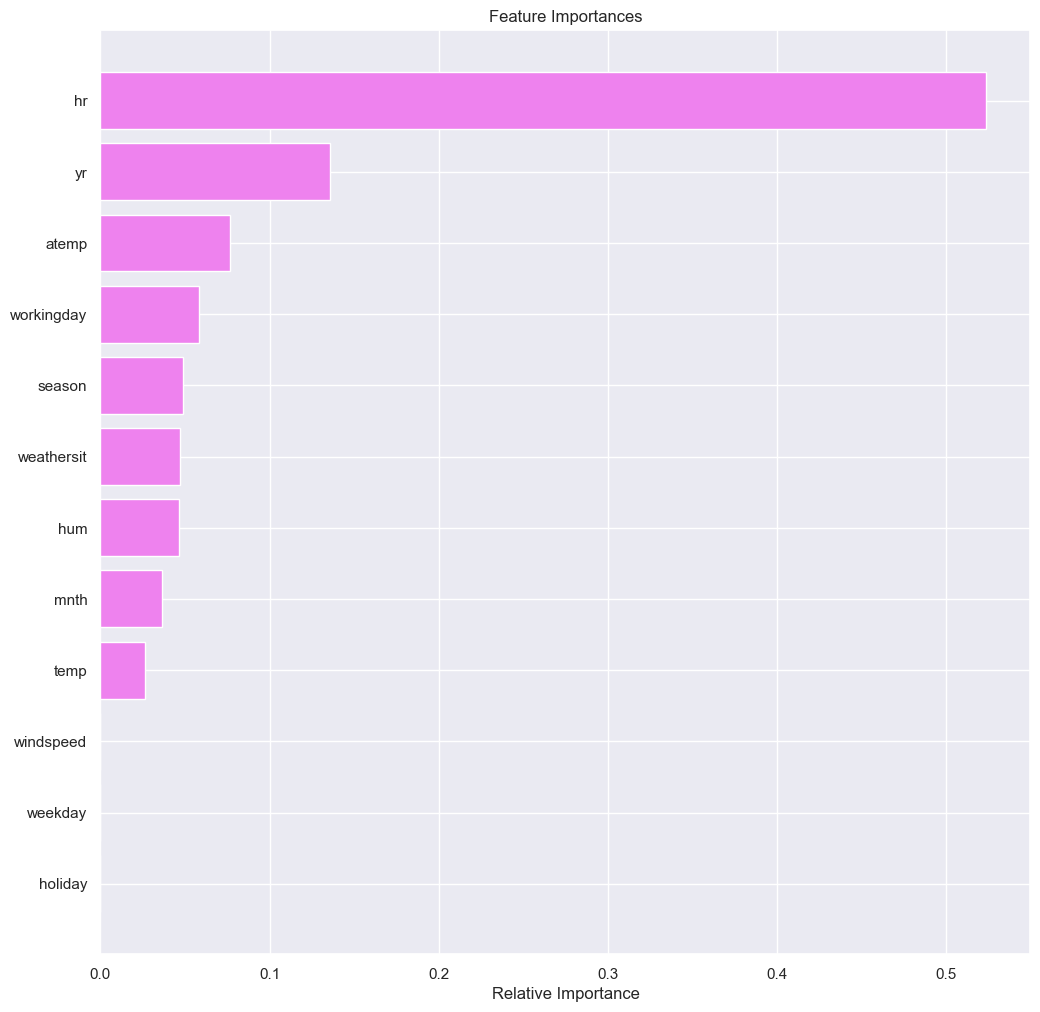

In [108]:
feature_names = X_train.columns
importances = ab_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), 
         importances[indices], 
         color='violet', 
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Gradient Boosting Regressor

In [110]:
gb_estimator=GradientBoostingRegressor(random_state=1).fit(X_train,
                                                           y_train)

gb_estimator_model_train_perf = model_performance(gb_estimator,
                                                  X_train,
                                                  y_train)
print("Training performance \n",gb_estimator_model_train_perf)

gb_estimator_model_test_perf = model_performance(gb_estimator, 
                                                 X_test, 
                                                 y_test)
print("Testing performance \n",gb_estimator_model_test_perf)

Training performance 
        RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  71.87459  48.518039   0.839959        0.839801  92.152544
Testing performance 
         RMSE        MAE  R-squared  Adj. R-squared        MAPE
0  74.173279  49.691124    0.83975         0.83938  100.149788


### Gradient Boosting Regressor - Hyperparameter Tuning

In [111]:
gb_tuned = GradientBoostingRegressor(random_state=1)

parameters = {
    'n_estimators': np.arange(50,200,25),
    'subsample': [0.7, 0.8, 0.9, 1],
    'max_features': [0.7, 0.8, 0.9, 1],
    'max_depth': [3,5,7,10]}

scorer = metrics.make_scorer(metrics.r2_score)

grid_obj = GridSearchCV(gb_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train,y_train)
gb_tuned = grid_obj.best_estimator_
gb_tuned.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=7, max_features=0.9, n_estimators=175,
                          random_state=1, subsample=0.7)

In [112]:
gb_tuned_model_train_perf = model_performance(gb_tuned, 
                                              X_train,
                                              y_train)
print("Training performance \n",gb_tuned_model_train_perf)

gb_tuned_model_test_perf = model_performance(gb_tuned, 
                                             X_test, 
                                             y_test)
print("Testing performance \n",gb_tuned_model_test_perf)

Training performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  22.272348  14.726501   0.984632        0.984617  23.168969
Testing performance 
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  39.076262  24.101884   0.955524        0.955421  36.01227


In [113]:
print(pd.DataFrame(gb_tuned.feature_importances_, 
                   columns = ["Imp"], 
                   index = X_train.columns)
      .sort_values(by = 'Imp', ascending = False))

                 Imp
hr          0.577712
temp        0.099255
workingday  0.083006
yr          0.081833
atemp       0.046505
hum         0.024214
season      0.024071
weathersit  0.020767
weekday     0.018315
mnth        0.013716
windspeed   0.007647
holiday     0.002959


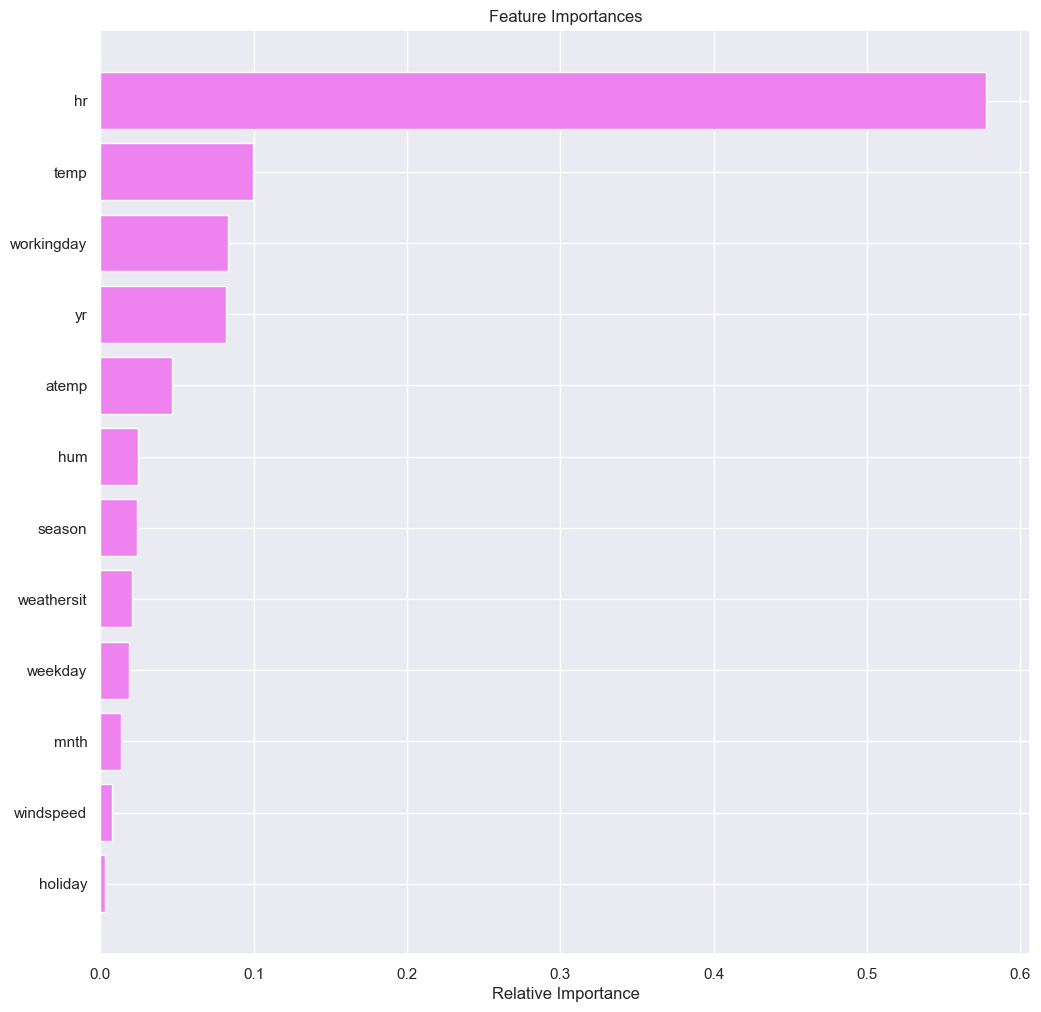

In [114]:
feature_names = X_train.columns
importances = gb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), 
         importances[indices], 
         color='violet', 
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## XGBoost Regressor

In [115]:
xgb_estimator = XGBRegressor(random_state=1, verbosity=0).fit(X_train,
                                                              y_train)

xgb_estimator_model_train_perf = model_performance(xgb_estimator, X_train, y_train)
print("Training performance \n",xgb_estimator_model_train_perf)

xgb_estimator_model_test_perf = model_performance(xgb_estimator, X_test,y_test)
print("Testing performance \n",xgb_estimator_model_test_perf)

Training performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  26.871925  17.489361   0.977629        0.977607  29.897491
Testing performance 
        RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  40.97643  25.816218   0.951093         0.95098  44.233734


### XGBoost Regressor - Hyperparameter Tuning

In [116]:
xgb_tuned = XGBRegressor(random_state=1,verbosity=0)

parameters= {
    'n_estimators': [75,100,125,150],
    'subsample': [0.7, 0.8, 0.9, 1],
    'gamma': [0,1,3,5],
    'colsample_bytree': [0.7, 0.8, 0.9, 1],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1]}

scorer = metrics.make_scorer(metrics.r2_score)
grid_obj = GridSearchCV(xgb_tuned,
                        parameters,
                        scoring=scorer,
                        cv=5).fit(X_train, y_train)

xgb_tuned = grid_obj.best_estimator_
xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None, colsample_bylevel=1,
             colsample_bynode=None, colsample_bytree=0.8, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=5, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [117]:
xgb_tuned_model_train_perf = model_performance(xgb_tuned, X_train, y_train)
print("Training performance \n",xgb_tuned_model_train_perf)

xgb_tuned_model_test_perf = model_performance(xgb_tuned, X_test, y_test)
print("Testing performance \n",xgb_tuned_model_test_perf)

Training performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  24.089582  15.880569   0.982022        0.982004  29.684937
Testing performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  41.709459  26.212988   0.949327        0.949211  47.762577


In [118]:
print(pd.DataFrame(xgb_tuned.feature_importances_, 
                   columns = ["Imp"], 
                   index = X_train.columns)
      .sort_values(by = 'Imp', ascending = False))

                 Imp
workingday  0.303633
hr          0.247001
yr          0.158463
atemp       0.112543
season      0.055415
weathersit  0.037744
temp        0.024362
weekday     0.015641
hum         0.015628
holiday     0.014147
mnth        0.011229
windspeed   0.004195


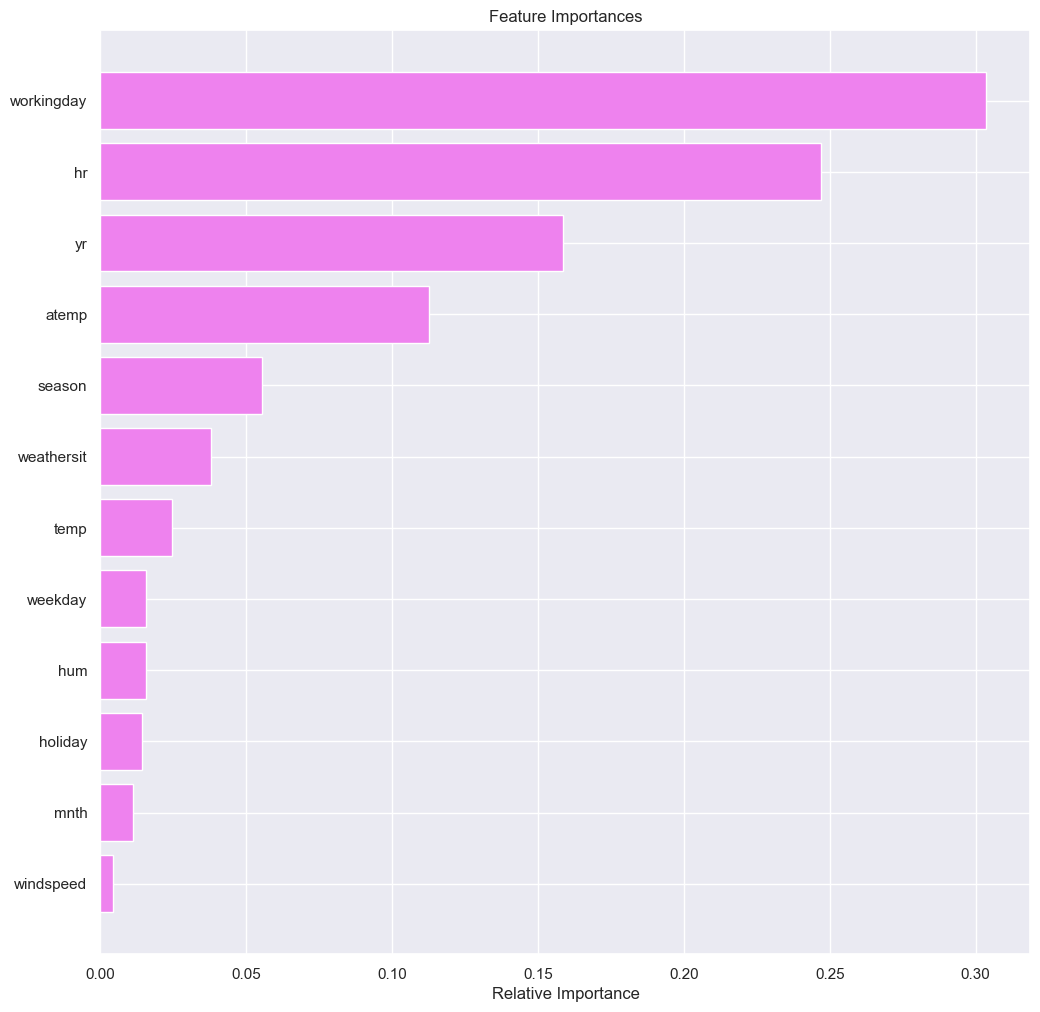

In [119]:
feature_names = X_train.columns
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), 
         importances[indices], 
         color='violet', 
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Stacking Model

In [120]:
estimators=[('Decision Tree', dtree_tuned),
            ('Random Forest', rf_tuned),
            ('Gradient Boosting', gb_tuned)]
final_estimator=XGBRegressor(random_state=1)

In [121]:
stacking_estimator=StackingRegressor(estimators=estimators, 
                                     final_estimator=final_estimator,
                                     cv=5).fit(X_train,y_train)

In [122]:
stacking_estimator_model_train_perf = model_performance(stacking_estimator,
                                                        X_train,
                                                        y_train)
print("Training performance \n",stacking_estimator_model_train_perf)

stacking_estimator_model_test_perf = model_performance(stacking_estimator,
                                                       X_test,
                                                       y_test)
print("Testing performance \n",stacking_estimator_model_test_perf)

Training performance 
         RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  23.623224  14.289185   0.982711        0.982694  16.205073
Testing performance 
        RMSE        MAE  R-squared  Adj. R-squared       MAPE
0  42.48249  25.127241   0.947432         0.94731  29.702946


## Comparing Models

In [123]:
# training performance comparison

models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T, 
     dtree_tuned_model_train_perf.T, 
     rf_estimator_model_train_perf.T,
     rf_tuned_model_train_perf.T,
     ab_regressor_model_train_perf.T,
     ab_tuned_model_train_perf.T,
     gb_estimator_model_train_perf.T,
     gb_tuned_model_train_perf.T,
     xgb_estimator_model_train_perf.T,
     xgb_tuned_model_train_perf.T,
     stacking_estimator_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
    "Stacking Classifier"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree,Decision Tree Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned,Stacking Classifier
RMSE,0.442409,36.442792,16.167421,16.160093,104.441843,103.326379,71.874590,22.272348,26.871925,24.089582,23.623224
MAE,0.005754,22.525337,9.641324,9.622604,80.996029,80.468809,48.518039,14.726501,17.489361,15.880569,14.289185
R-squared,0.999994,0.958856,0.991902,0.991910,0.662067,0.669247,0.839959,0.984632,0.977629,0.982022,0.982711
Adj. R-squared,0.999994,0.958816,0.991894,0.991902,0.661733,0.668920,0.839801,0.984617,0.977607,0.982004,0.982694
MAPE,0.004256,28.657314,11.757327,11.734320,185.877344,195.189129,92.152544,23.168969,29.897491,29.684937,16.205073


In [124]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T, 
     dtree_tuned_model_test_perf.T, 
     rf_estimator_model_test_perf.T,
     rf_tuned_model_test_perf.T,
     ab_regressor_model_test_perf.T,
     ab_tuned_model_test_perf.T,
     gb_estimator_model_test_perf.T,
     gb_tuned_model_test_perf.T,
     xgb_estimator_model_test_perf.T,
     xgb_tuned_model_test_perf.T,
     stacking_estimator_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree",
    "Decision Tree Tuned",
    "Random Forest Estimator",
    "Random Forest Tuned",
    "Adaboost Regressor",
    "Adaboost Tuned",
    "Gradient Boost Estimator",
    "Gradient Boost Tuned",
    "XGB",
    "XGB Tuned",
    "Stacking Classifier"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Decision Tree,Decision Tree Tuned,Random Forest Estimator,Random Forest Tuned,Adaboost Regressor,Adaboost Tuned,Gradient Boost Estimator,Gradient Boost Tuned,XGB,XGB Tuned,Stacking Classifier
RMSE,60.827833,54.969957,44.562150,44.580600,105.415729,104.430458,74.173279,39.076262,40.976430,41.709459,42.482490
MAE,35.107787,31.841364,26.192368,26.202363,81.468364,81.015165,49.691124,24.101884,25.816218,26.212988,25.127241
R-squared,0.892227,0.911985,0.942159,0.942111,0.676321,0.682343,0.839750,0.955524,0.951093,0.949327,0.947432
Adj. R-squared,0.891979,0.911782,0.942026,0.941977,0.675574,0.681610,0.839380,0.955421,0.950980,0.949211,0.947310
MAPE,38.033250,38.356397,32.748634,32.734172,196.403082,207.467888,100.149788,36.012270,44.233734,47.762577,29.702946


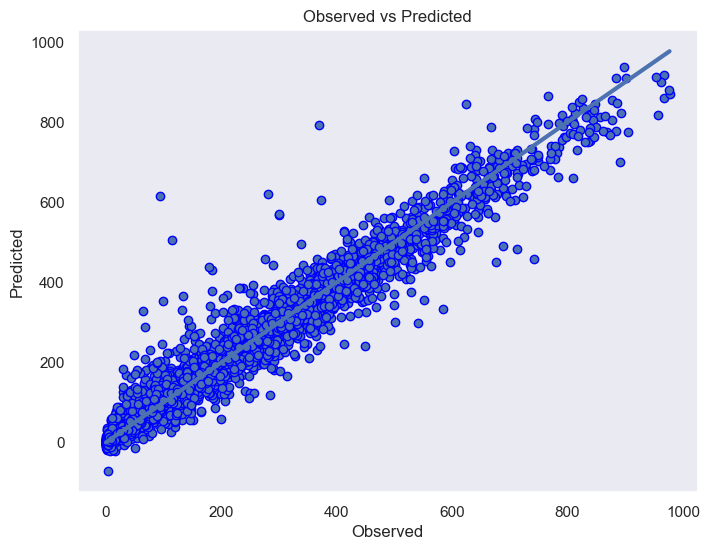

In [127]:
fig, ax = plt.subplots(figsize=(8,6))
y_pred=gb_tuned.predict(X_test)
ax.scatter(y_test, 
           y_pred,
           edgecolor=(0,0,1))
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        lw=3)
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_title('Observed vs Predicted')
plt.grid()
plt.show()

## <a name='link1'>Appendix: Detailed Exploratory Data Analysis (EDA)</a>

### Univariate analysis

#### Observations on temperature

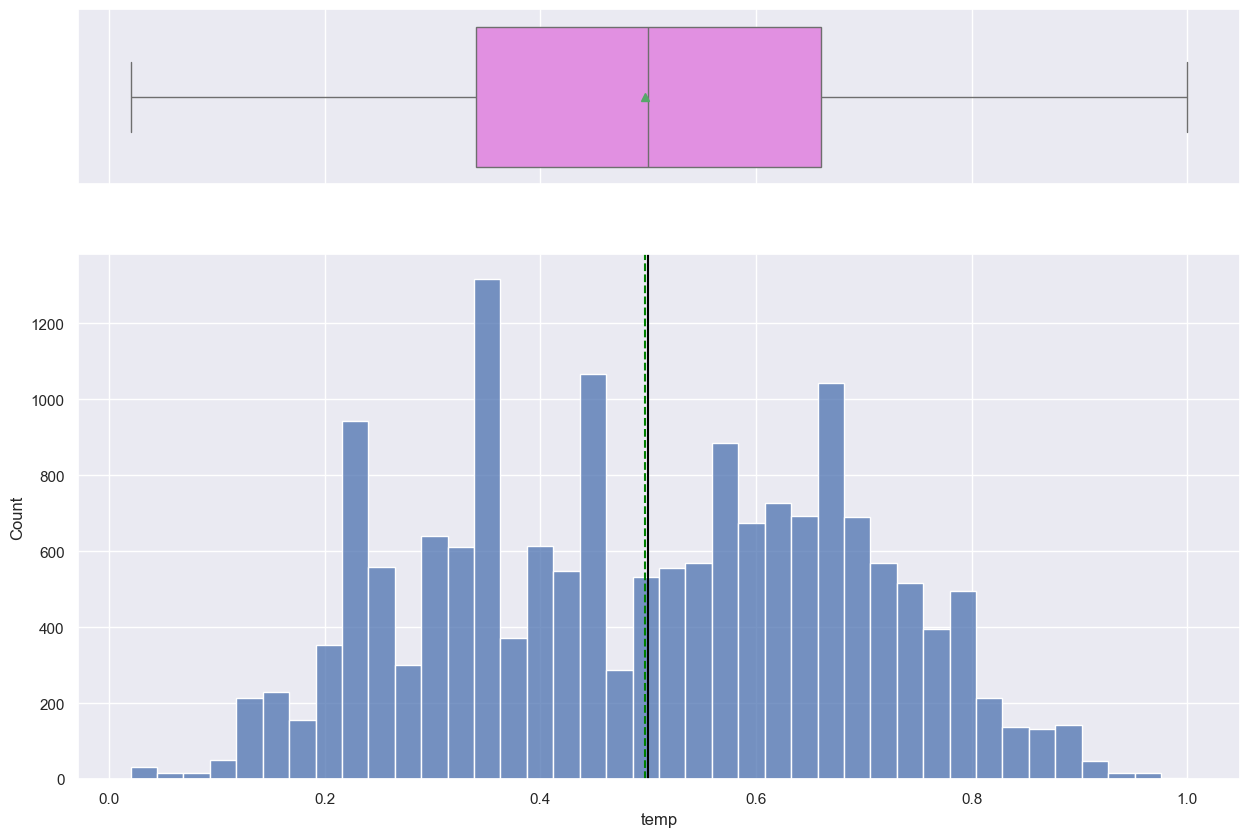

In [128]:
histogram_boxplot(df, "temp")

#### Observations on 'feel like temperature

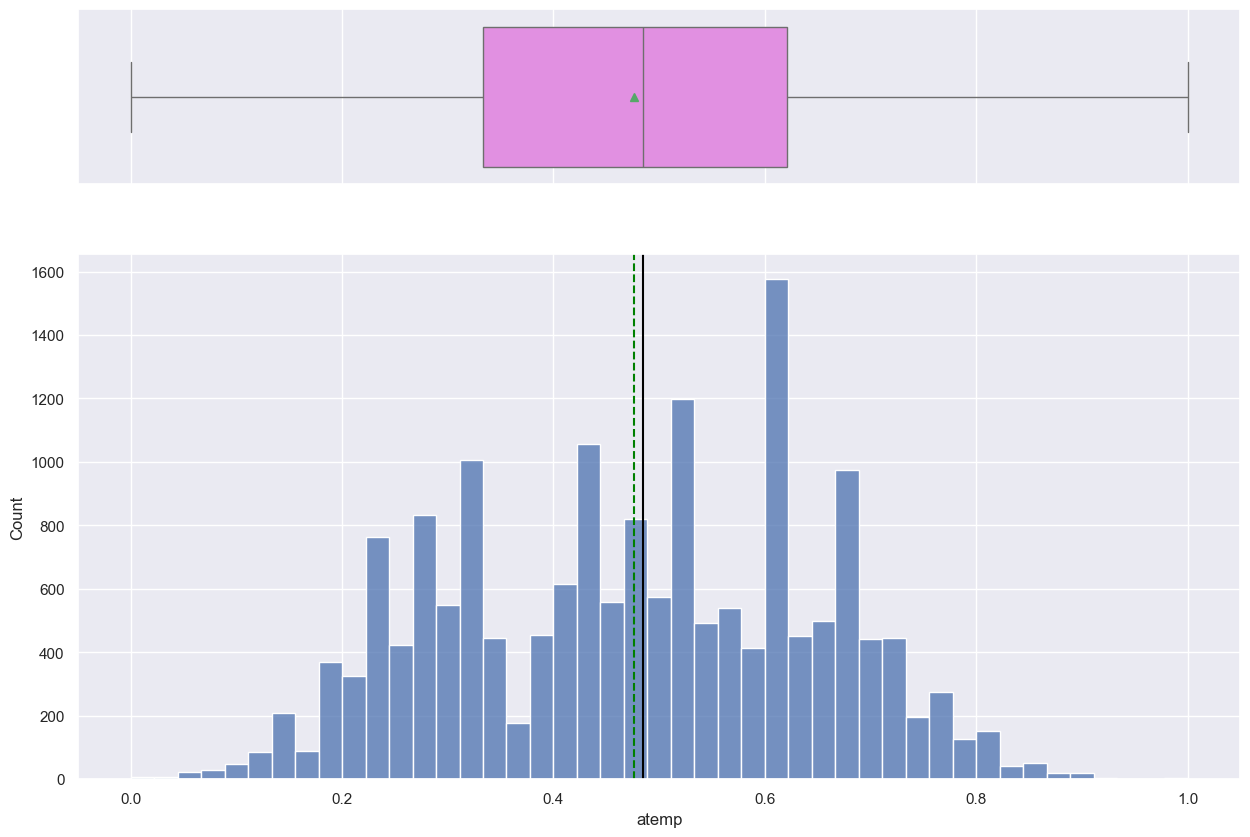

In [129]:
histogram_boxplot(df, "atemp")

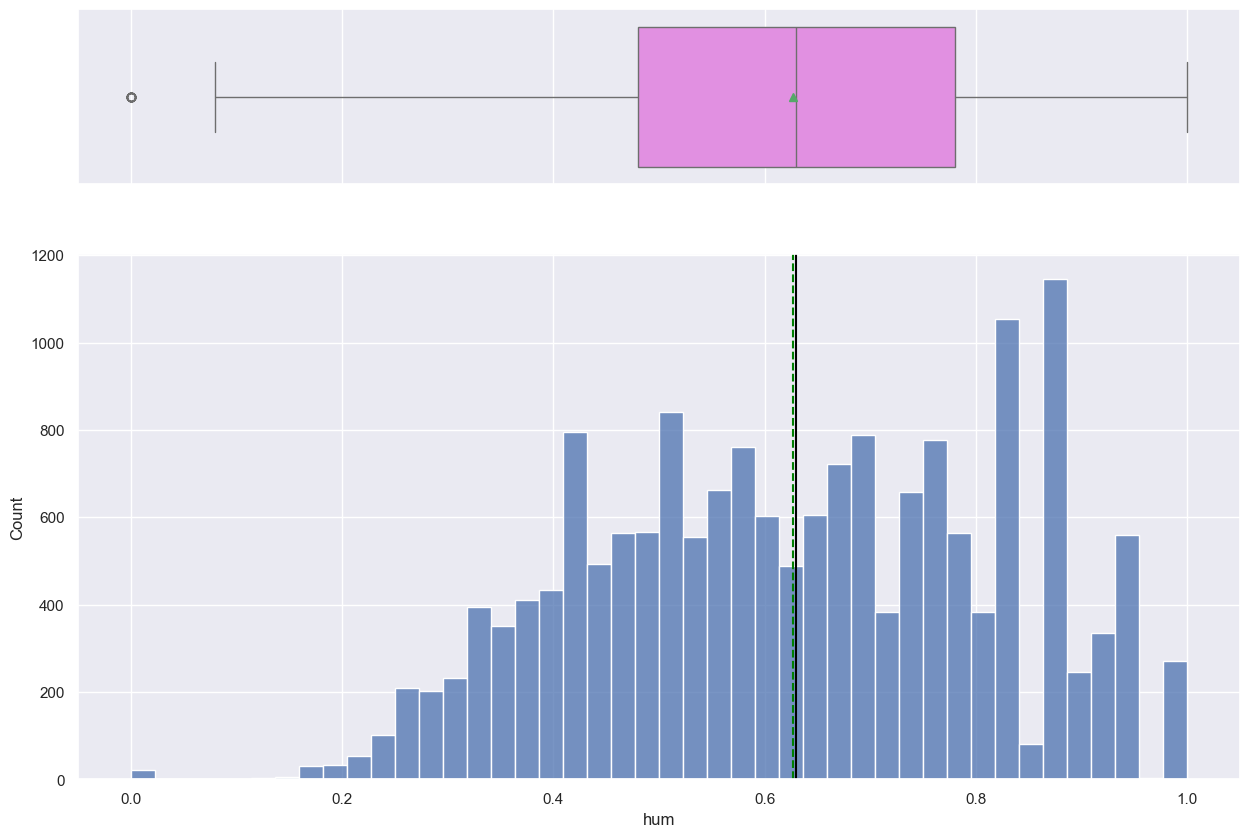

In [130]:
histogram_boxplot(df,"hum")

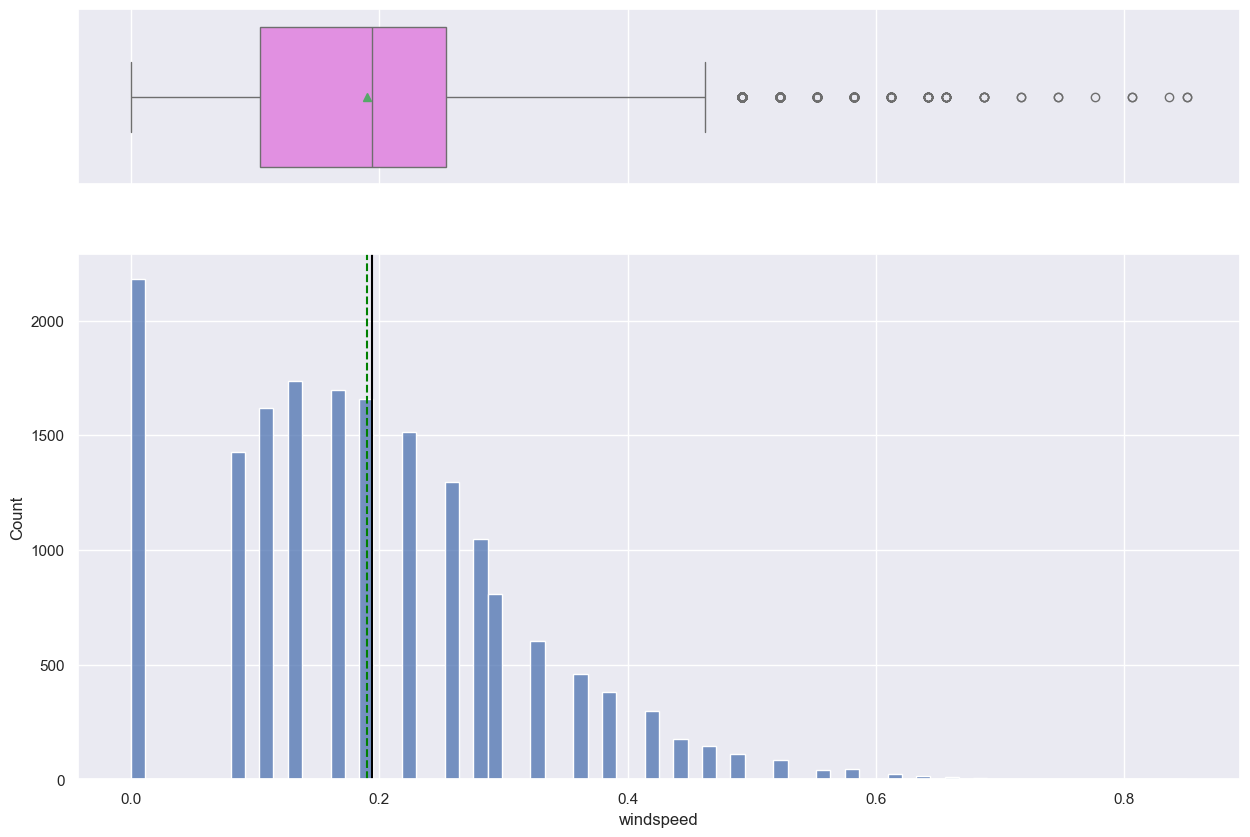

In [131]:
histogram_boxplot(df,'windspeed')

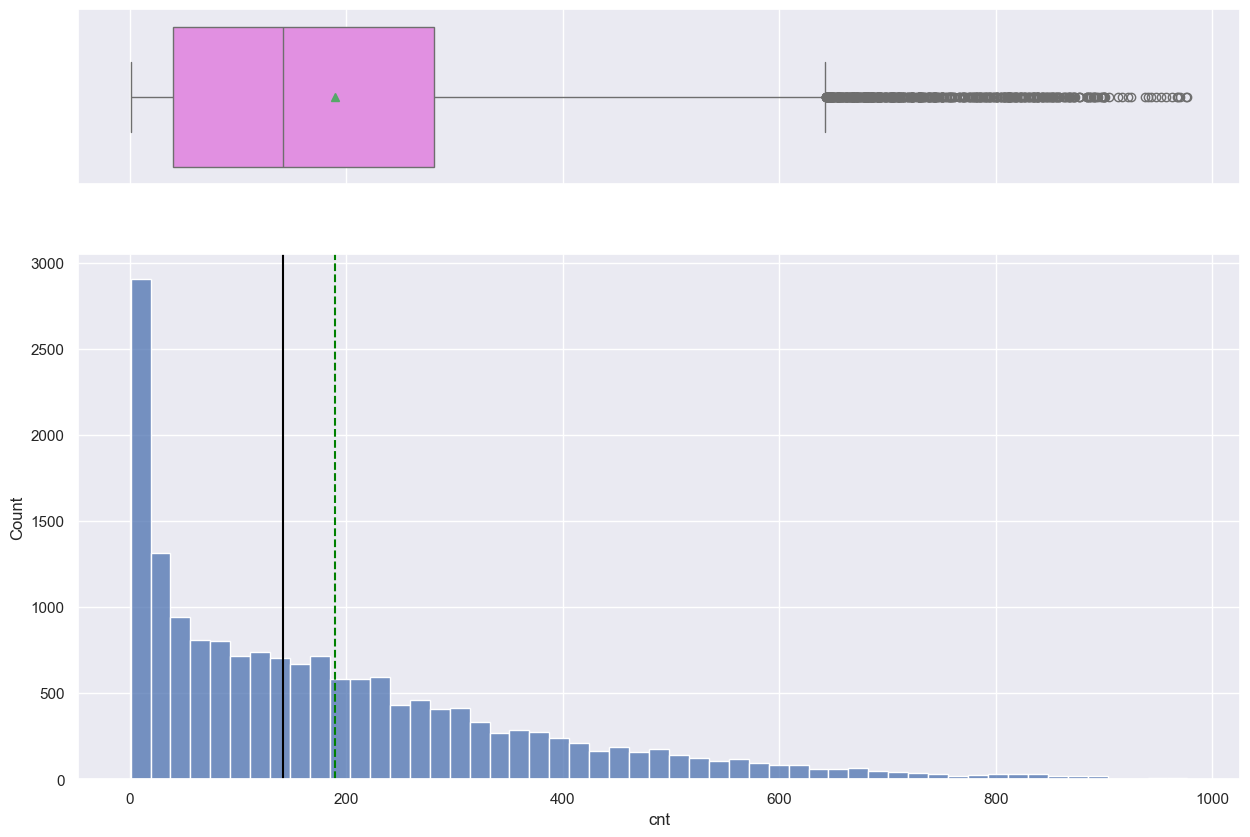

In [132]:
histogram_boxplot(df,'cnt')

In [133]:
#Top 5 highest values
df['cnt'].nlargest()

14773    977
14964    976
14748    970
14725    968
15084    967
Name: cnt, dtype: int64

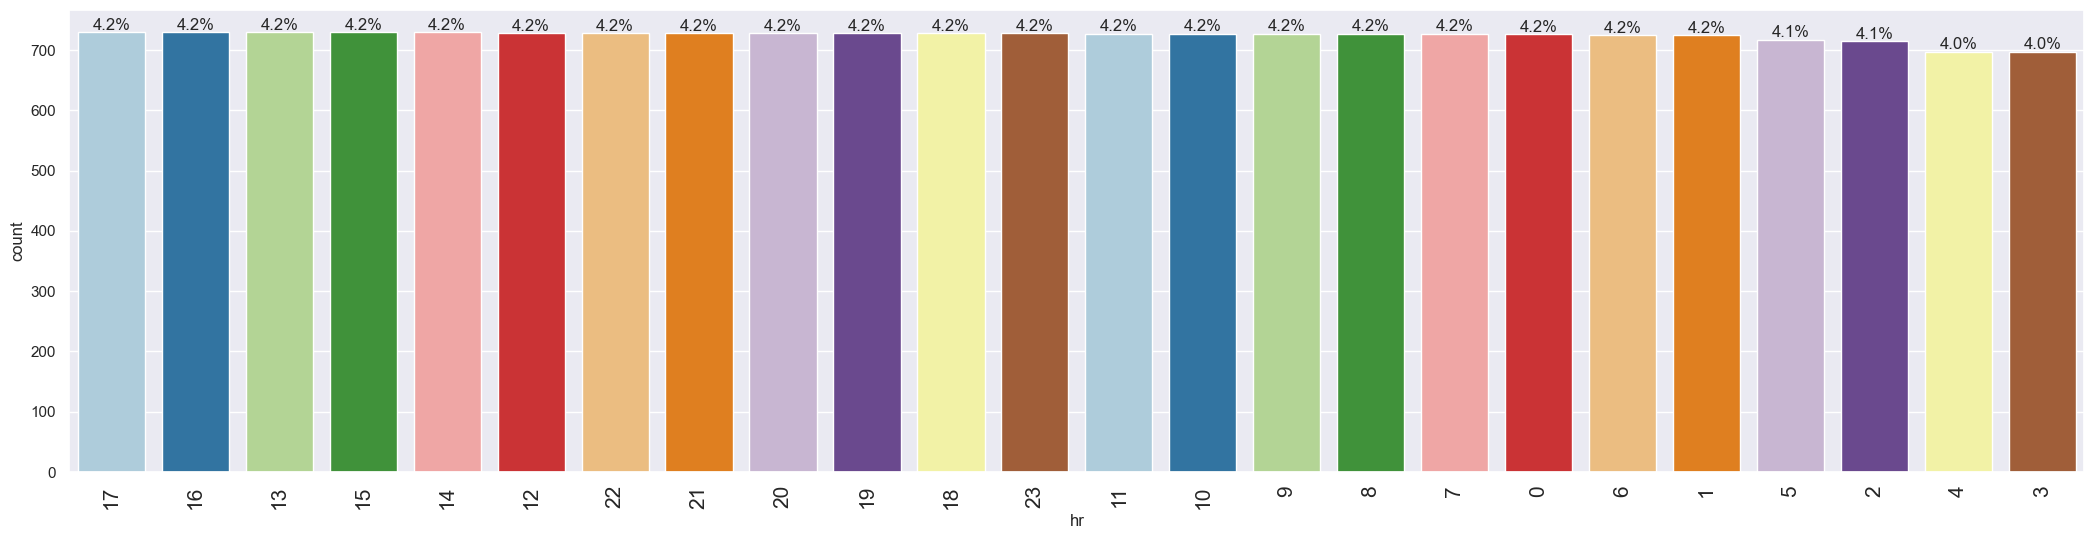

In [134]:
labeled_barplot(df, "hr",perc=True)

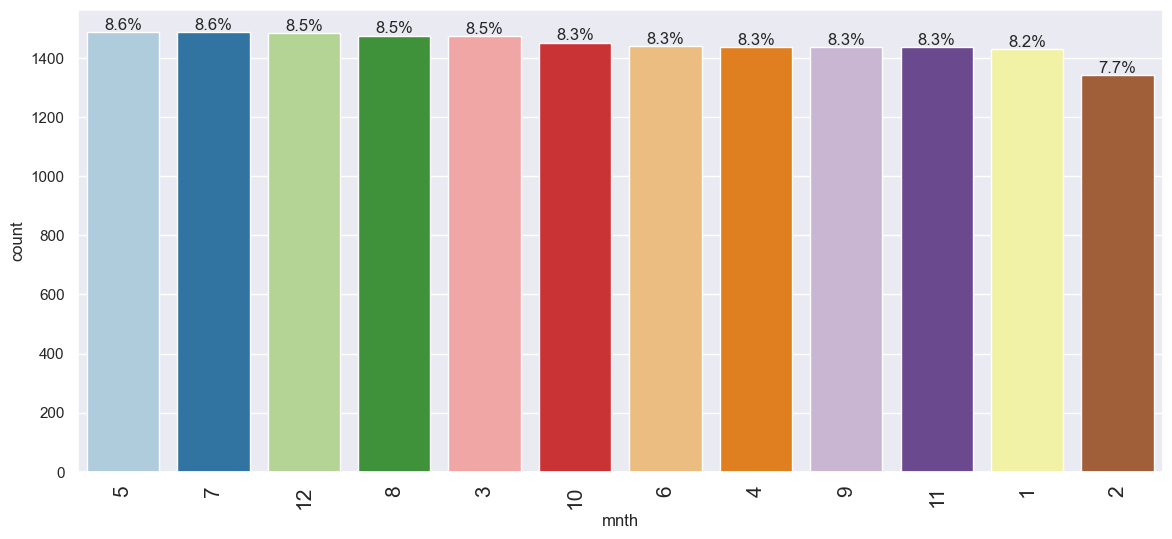

In [135]:
labeled_barplot(df,'mnth',perc=True)

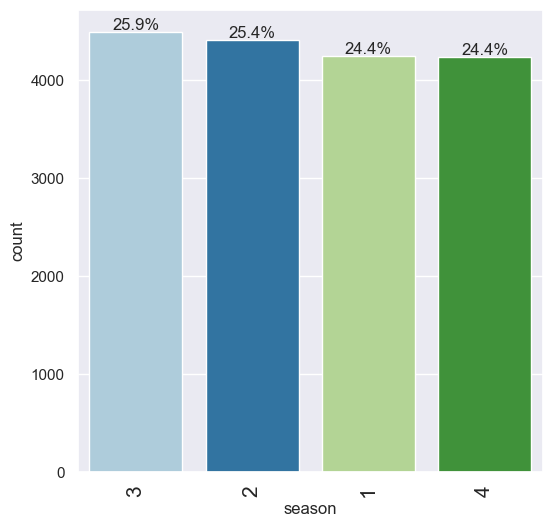

In [136]:
labeled_barplot(df,'season',perc=True)

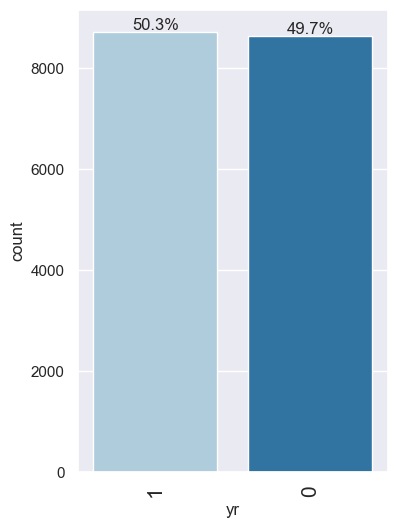

In [137]:
labeled_barplot(df,'yr',perc=True)

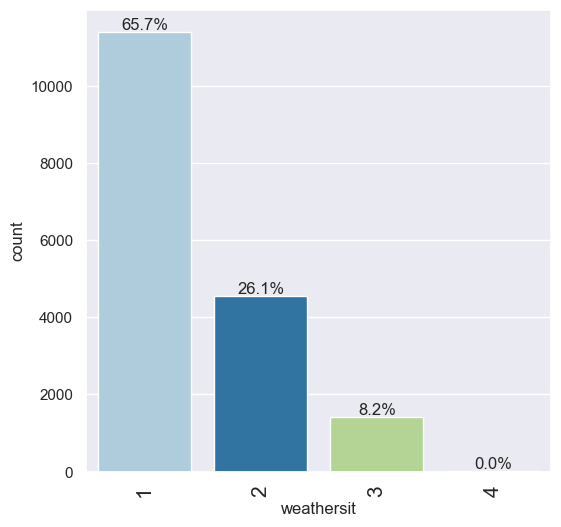

In [138]:
labeled_barplot(df,'weathersit',perc=True)

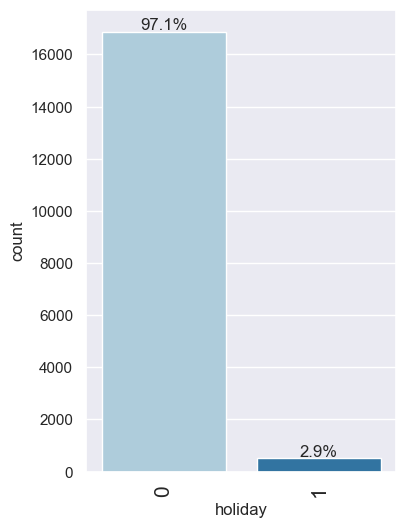

In [139]:
labeled_barplot(df,'holiday',perc=True)

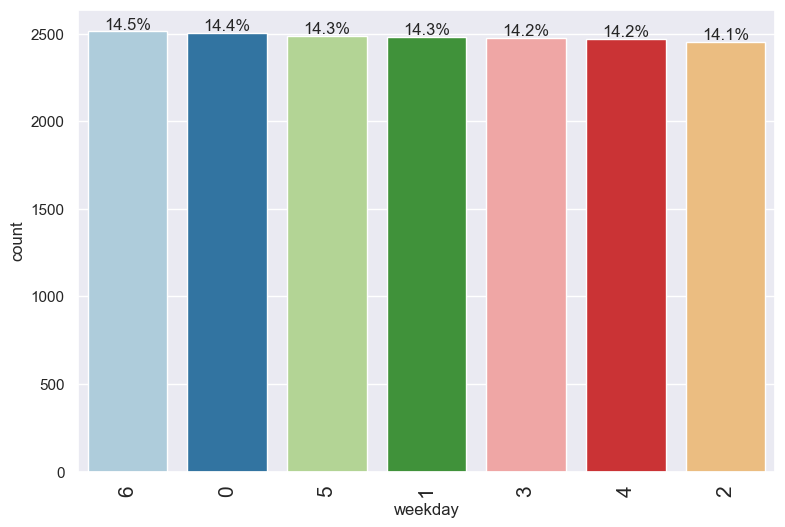

In [140]:
labeled_barplot(df,'weekday',perc=True)

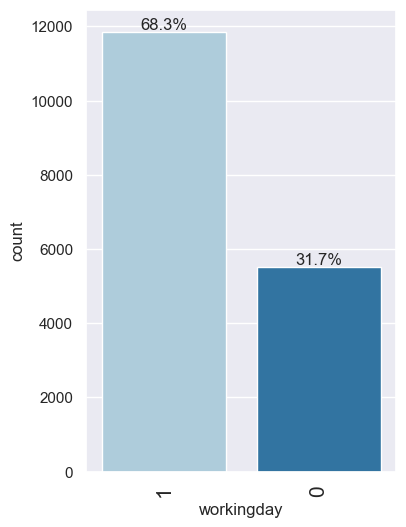

In [141]:
labeled_barplot(df,'workingday',perc=True)

### Bivariate analysis

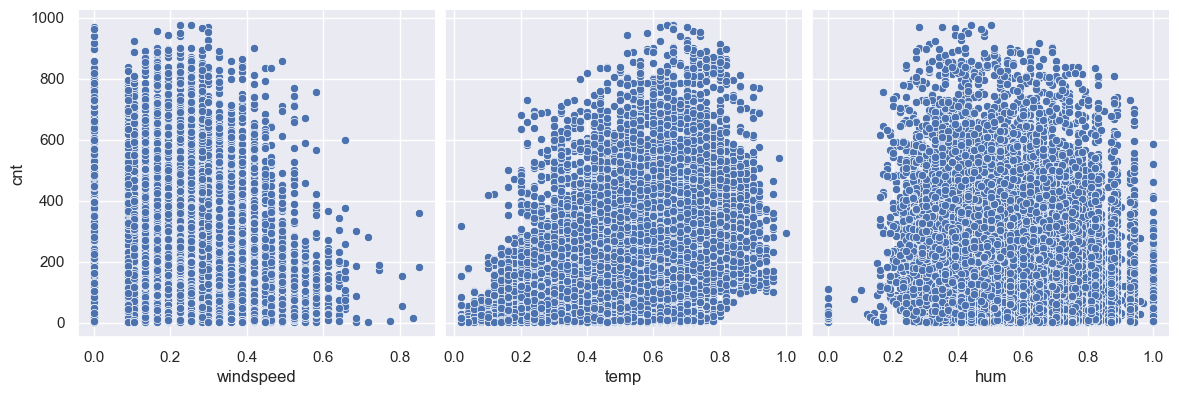

In [142]:
sns.pairplot(
    df,
    x_vars=["windspeed", "temp", "hum"],
    y_vars=["cnt"],
    height=4,
    aspect=1
    );

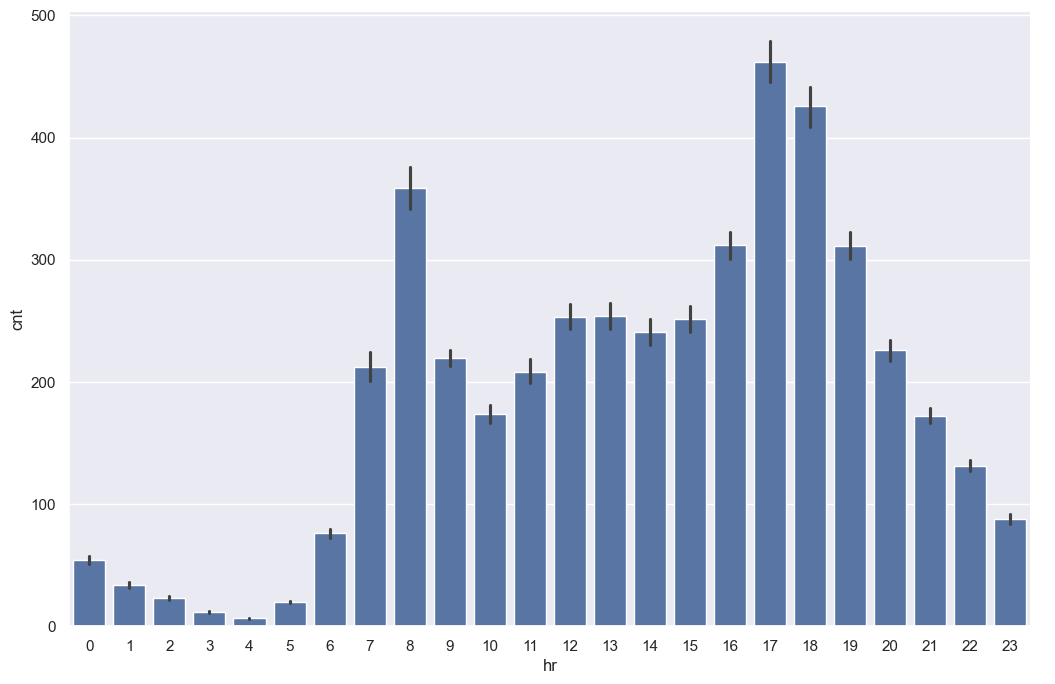

In [143]:
sns.catplot(x="hr", 
            y="cnt", 
            data=df, 
            kind='bar', 
            height=7, 
            aspect=1.5, 
            estimator=np.mean);

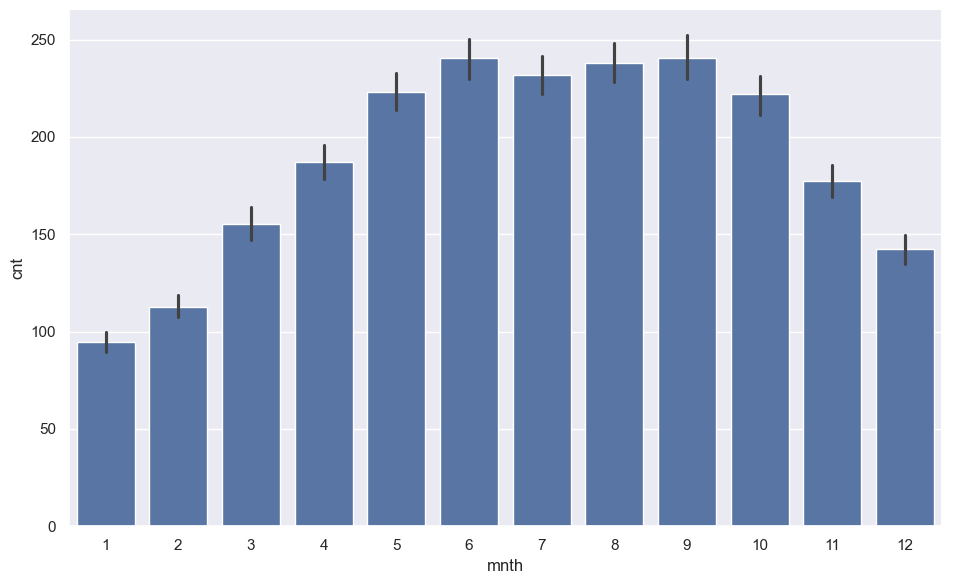

In [144]:
sns.catplot(x="mnth", 
            y="cnt", 
            data=df, 
            kind='bar', 
            height=6, 
            aspect=1.6, 
            estimator=np.mean);

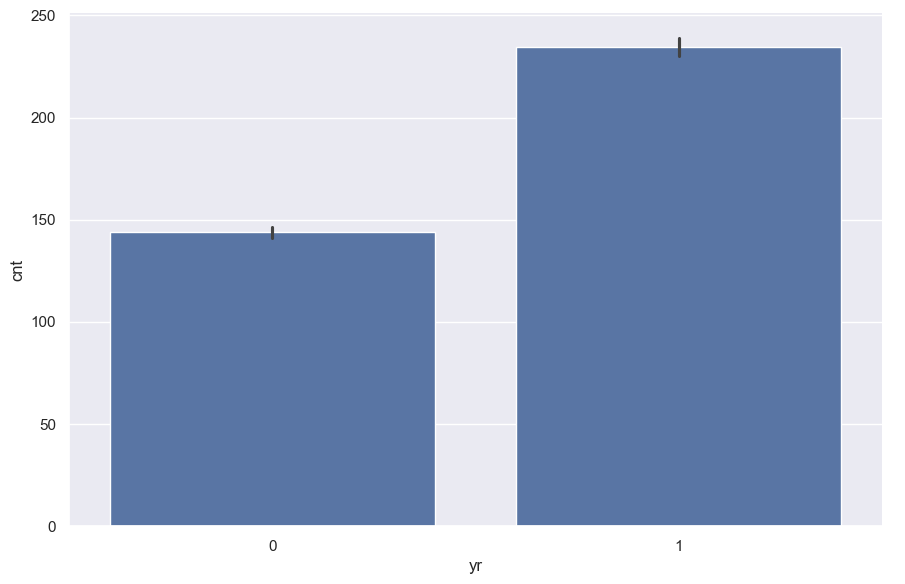

In [149]:
sns.catplot(x='yr', 
            y='cnt', 
            data=df, 
            kind='bar', 
            height=6, 
            aspect=1.5, 
            estimator=np.mean);

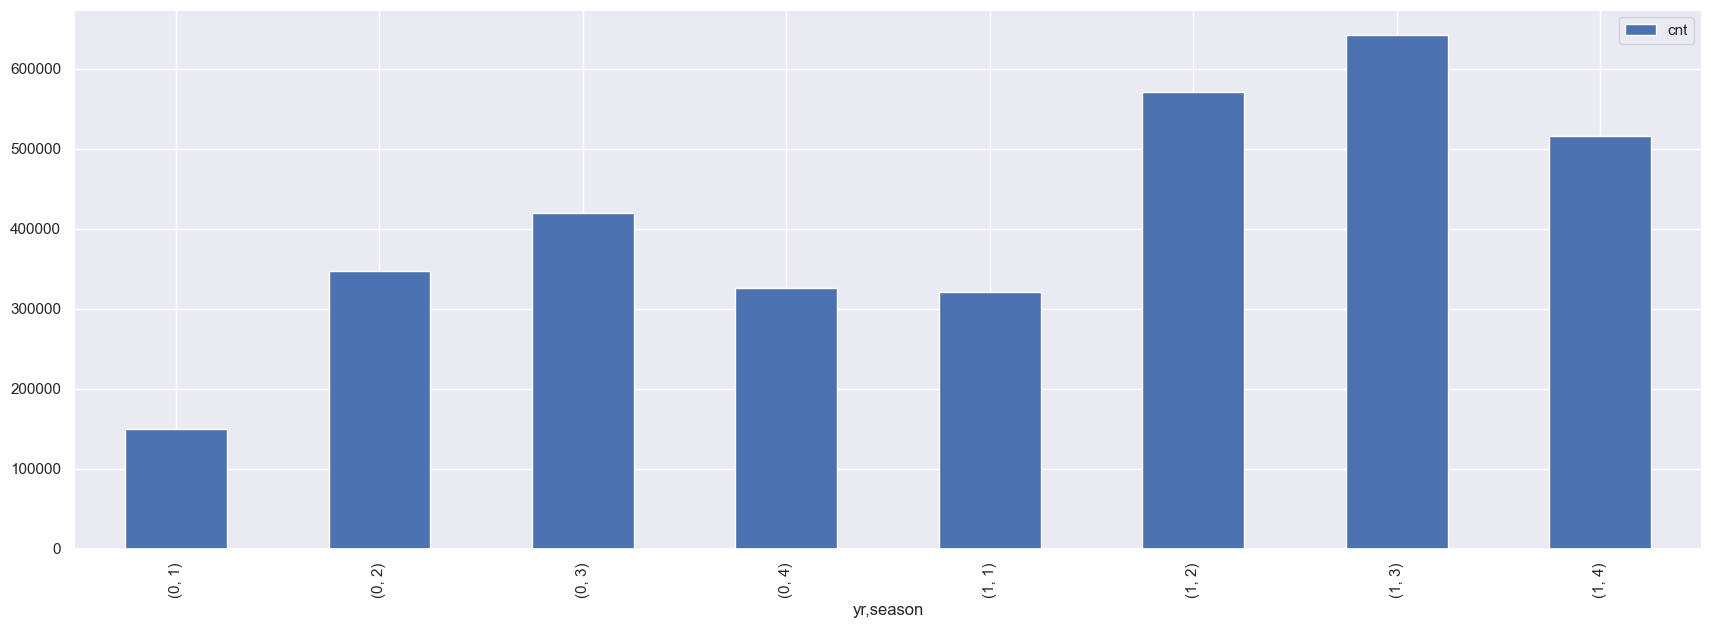

In [150]:

pd.pivot_table(data=df, 
               index=['yr', 'season'], 
               values='cnt', 
               aggfunc=np.sum).plot(kind='bar');

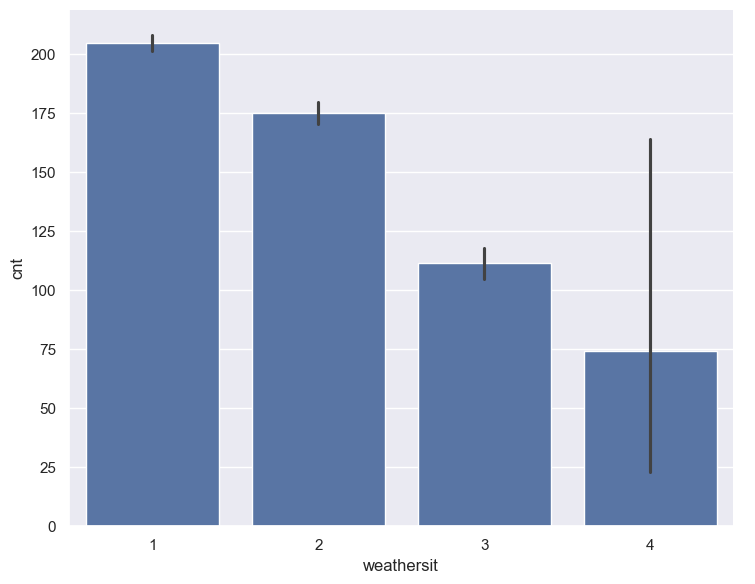

In [155]:
sns.catplot(x="weathersit", 
            y='cnt', 
            kind='bar', 
            data=df, 
            height=6, 
            aspect=1.25, 
            estimator=np.mean);

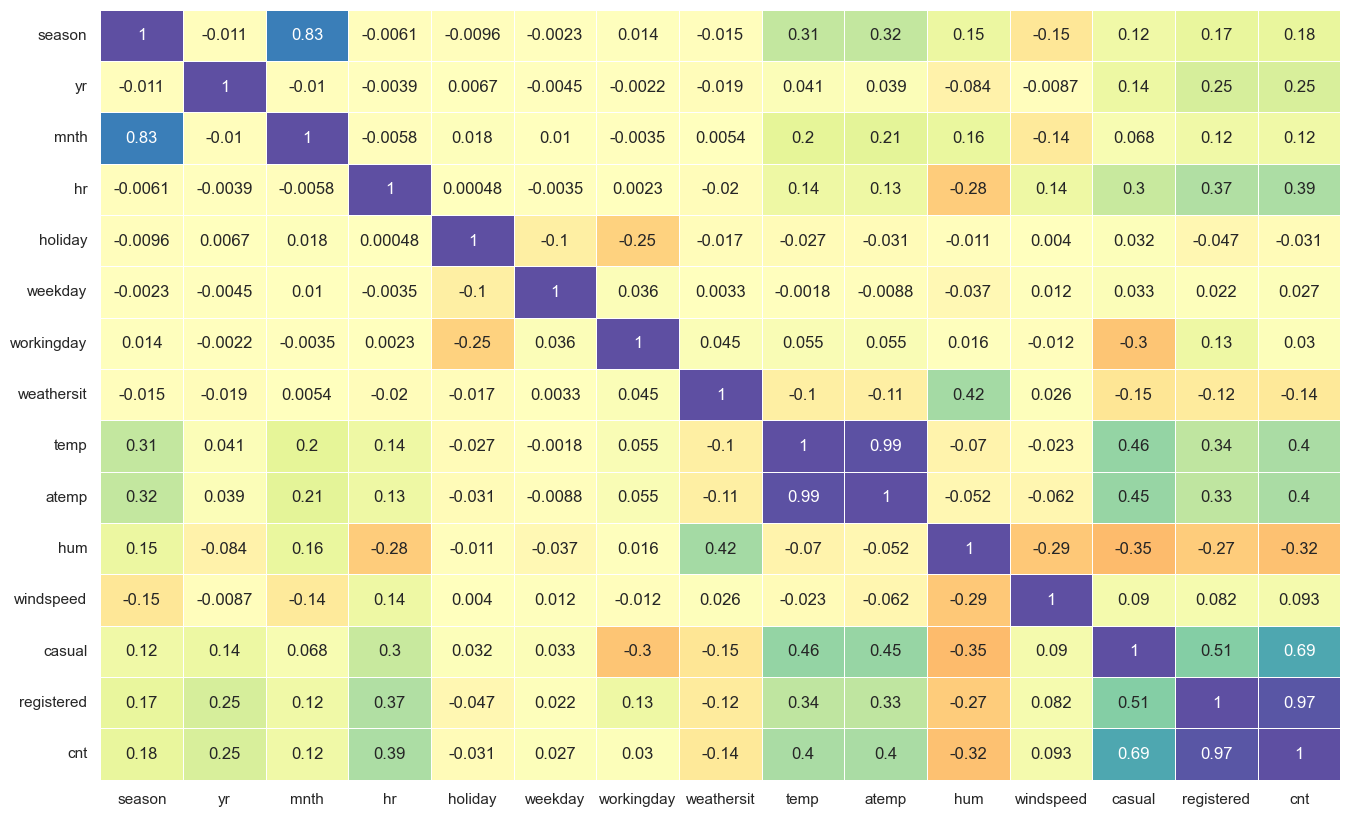

In [157]:
sns.set(rc={'figure.figsize':(16,10)})
sns.heatmap(df.corr(),
            annot=True,
            linewidths=.5,
            center=0,
            cbar=False,
            cmap="Spectral")
plt.show()

### To jump back to the EDA summary section, click <a href = #link2>here</a>.